# VoD Radar-LiDAR Hybrid Risk Pipeline 재설계

본 노트북은 기존 leakage 분석 결과를 반영해 위험도 파이프라인을 전면 재설계한 버전입니다.

## 핵심 원칙
- **Rule-based 위험도**와 **ML-based refinement**를 명확히 분리
- **누설 금지**: `ttc`, `range_xy`, `abs_vr_comp`는 ML 입력에서 제외
- **평가 정직성 우선**: random split 기본 금지, group/time split 중심
- 정확도 자랑보다 **위험 후보 우선순위화**와 **high/medium recall** 중시

## 최종 파이프라인
Radar point cloud
→ 전처리
→ cluster proposal 생성
→ LiDAR corroboration
→ temporal tracking
→ rule-based risk scoring
→ ML-based refinement/confidence
→ BEV 위험지역 시각화

## 노트북 구성
1. Radar 로딩/전처리 + EDA
2. Cluster proposal (DBSCAN vs HDBSCAN)
3. LiDAR corroboration
4. Temporal tracking (baseline vs improved)
5. Rule-based risk scoring
6. ML-based refinement (anti-leakage)
7. Leakage vs honest 평가 비교
8. BEV 통합 시각화 + PNG/GIF 저장
9. 발표용 결론

## 0. 공통 Import + 한글 폰트 설정

In [1]:
from __future__ import annotations

import logging
import math
import os
import random
import sys
import warnings
from collections import defaultdict
from pathlib import Path
from typing import Any

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
from matplotlib.patches import Circle
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    r2_score,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_sample_weight

try:
    from scipy.optimize import linear_sum_assignment
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False

try:
    import hdbscan
    HDBSCAN_OK = True
except Exception:
    HDBSCAN_OK = False

NOTEBOOK_DIR = Path.cwd().resolve()
sys.path.insert(0, str(NOTEBOOK_DIR))

import bev_lidar_detector_train as bev
import vod_hybrid_pipeline_v2 as v2
from scipy.stats import kendalltau, spearmanr

warnings.filterwarnings("ignore")
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# 한글 폰트
FONT_PATH = "C:/Windows/Fonts/malgun.ttf"
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
if Path(FONT_PATH).is_file():
    font_manager.fontManager.addfont(FONT_PATH)
    primary_font = font_manager.FontProperties(fname=FONT_PATH).get_name()
else:
    primary_font = "Malgun Gothic" if "Malgun Gothic" in available_fonts else None

font_candidates = [primary_font, "Malgun Gothic", "NanumGothic", "DejaVu Sans"]
active_fonts = []
for fam in font_candidates:
    if fam and fam in available_fonts and fam not in active_fonts:
        active_fonts.append(fam)

sns.set_theme(style="whitegrid")
if active_fonts:
    rc("font", family=active_fonts)
    matplotlib.rcParams["font.family"] = active_fonts
rc("axes", unicode_minus=False)
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120

print("ready:", NOTEBOOK_DIR)
print("active fonts:", matplotlib.rcParams.get("font.family"))
print("HDBSCAN available:", HDBSCAN_OK, "| SCIPY available:", SCIPY_OK)
if not HDBSCAN_OK:
    print("[안내] HDBSCAN 미설치 시 DBSCAN만 비교됩니다. 설치: python -m pip install hdbscan (동일 커널 환경)")

ready: C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit
active fonts: ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
HDBSCAN available: False | SCIPY available: True


## 1. 설정 및 데이터 로딩

In [2]:
DEFAULT_ROOT = NOTEBOOK_DIR / "vod-received" / "view_of_delft_PUBLIC"
DATASET_ROOT = Path(os.environ.get("VOD_ROOT", str(DEFAULT_ROOT))).resolve()

RADAR_MODE = os.environ.get("VOD_RADAR_MODE", "5-scan")
MAX_FRAMES = int(os.environ.get("VOD_REDESIGN_MAX_FRAMES", "180"))
MAX_POINTS_PER_FRAME = int(os.environ.get("VOD_REDESIGN_MAX_POINTS_PER_FRAME", "2200"))

# ROI/전처리 파라미터
ROI = {
    "x_min": 0.0,
    "x_max": 70.0,
    "y_min": -35.0,
    "y_max": 35.0,
    "z_min": -3.5,
    "z_max": 4.0,
}
RCS_CLIP = (-35.0, 35.0)
SPEED_CLIP = (-25.0, 25.0)

# clustering
DBSCAN_EPS = float(os.environ.get("VOD_DBSCAN_EPS", "1.2"))
DBSCAN_MIN_SAMPLES = int(os.environ.get("VOD_DBSCAN_MIN_SAMPLES", "6"))
HDBSCAN_MIN_CLUSTER_SIZE = int(os.environ.get("VOD_HDBSCAN_MIN_CLUSTER_SIZE", "10"))

# LiDAR corroboration
LIDAR_VERIFY_RADIUS = float(os.environ.get("VOD_LIDAR_VERIFY_RADIUS", "1.8"))
LIDAR_DENSITY_RADIUS = float(os.environ.get("VOD_LIDAR_DENSITY_RADIUS", "2.0"))

# tracking
TRACK_GATE_DIST = float(os.environ.get("VOD_TRACK_GATE_DIST", "3.5"))
RADAR_DT_SEC = float(os.environ.get("VOD_RADAR_DT_SEC", str(1.0 / 13.0)))

frames_all = bev.list_vod_sync_frames(DATASET_ROOT, radar_mode=RADAR_MODE)
frames = [fr for fr in frames_all if fr["radar_path"] and Path(fr["radar_path"]).is_file()][:MAX_FRAMES]
if not frames:
    raise RuntimeError("Radar 프레임을 찾지 못했습니다. VOD_ROOT/RADAR_MODE 확인 필요")

frame_order_map = {fr["frame_id"]: i for i, fr in enumerate(frames)}
DEMO_FRAME_ID = os.environ.get("VOD_DEMO_FRAME", frames[len(frames)//2]["frame_id"])

print("DATASET_ROOT:", DATASET_ROOT)
print("RADAR_MODE:", RADAR_MODE)
print("사용 프레임:", len(frames), "/", len(frames_all))
print("DEMO_FRAME_ID:", DEMO_FRAME_ID)

DATASET_ROOT: C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\vod-received\view_of_delft_PUBLIC
RADAR_MODE: 5-scan
사용 프레임: 180 / 8682
DEMO_FRAME_ID: 00090


## 2. Step 1 — Radar 데이터 전처리 + EDA

In [3]:
RADAR_COLS = ["x", "y", "z", "RCS", "v_r", "v_r_compensated", "time"]


def preprocess_radar_points(pts: np.ndarray) -> np.ndarray:
    if pts.size == 0:
        return np.zeros((0, 7), dtype=np.float32)

    m = (
        (pts[:, 0] >= ROI["x_min"])
        & (pts[:, 0] <= ROI["x_max"])
        & (pts[:, 1] >= ROI["y_min"])
        & (pts[:, 1] <= ROI["y_max"])
        & (pts[:, 2] >= ROI["z_min"])
        & (pts[:, 2] <= ROI["z_max"])
    )
    out = pts[m].copy()
    if out.shape[0] == 0:
        return out

    out[:, 3] = np.clip(out[:, 3], RCS_CLIP[0], RCS_CLIP[1])
    out[:, 4] = np.clip(out[:, 4], SPEED_CLIP[0], SPEED_CLIP[1])
    out[:, 5] = np.clip(out[:, 5], SPEED_CLIP[0], SPEED_CLIP[1])

    # frame당 과도 포인트 샘플링
    if out.shape[0] > MAX_POINTS_PER_FRAME:
        rng = np.random.default_rng(SEED)
        idx = rng.choice(out.shape[0], size=MAX_POINTS_PER_FRAME, replace=False)
        out = out[idx]

    return out


def build_radar_dataframe(frames_subset: list[dict[str, Any]]) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    frame_rows = []
    for fr in frames_subset:
        frame_id = fr["frame_id"]
        arr = bev.parse_radar_bin(Path(fr["radar_path"]))
        proc = preprocess_radar_points(arr)

        if proc.shape[0] > 0:
            df = pd.DataFrame(proc, columns=RADAR_COLS)
            df["frame_id"] = frame_id
            df["frame_order"] = int(frame_order_map[frame_id])
            rows.append(df)

        frame_rows.append(
            {
                "frame_id": frame_id,
                "frame_order": int(frame_order_map[frame_id]),
                "raw_points": int(arr.shape[0]),
                "processed_points": int(proc.shape[0]),
                "kept_ratio": float(proc.shape[0] / max(arr.shape[0], 1)),
            }
        )

    radar_df_local = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=RADAR_COLS + ["frame_id", "frame_order"])
    frame_summary_local = pd.DataFrame(frame_rows)

    if not radar_df_local.empty:
        radar_df_local["range_xy"] = np.hypot(radar_df_local["x"], radar_df_local["y"])
        radar_df_local["abs_vr_comp"] = radar_df_local["v_r_compensated"].abs()

    return radar_df_local, frame_summary_local


radar_df, frame_summary = build_radar_dataframe(frames)
print("radar_df shape:", radar_df.shape)
display(frame_summary.head())
display(radar_df.head())

print("\n[EDA summary]")
eda_cols = ["x", "y", "z", "RCS", "v_r", "v_r_compensated", "range_xy", "abs_vr_comp"]
display(radar_df[eda_cols].describe(percentiles=[0.01, 0.1, 0.5, 0.9, 0.99]).T)

radar_df shape: (175703, 11)


,frame_id,frame_order,raw_points,processed_points,kept_ratio
0,00000,0,284,247,0.869718
1,00001,1,597,505,0.845896
2,00002,2,916,770,0.840611
3,00003,3,1242,1039,0.836554
4,00004,4,1590,1307,0.822013


,x,y,z,RCS,v_r,v_r_compensated,time,frame_id,frame_order,range_xy,abs_vr_comp
0,2.259143,-1.677923,-0.461345,-35.000000,-0.846359,0.003345,0.0,00000,0,2.814099,0.003345
1,2.892353,-1.702031,-0.484078,-35.000000,-0.945826,0.000521,0.0,00000,0,3.355982,0.000521
2,3.198316,-1.740433,-0.461826,-35.000000,-0.966848,0.008980,0.0,00000,0,3.641199,0.008980
3,5.296023,-1.029389,-0.228245,-21.281502,0.313759,1.494236,0.0,00000,0,5.395137,1.494236
4,4.892861,-1.705152,-0.610011,-31.324360,-1.089766,0.004509,0.0,00000,0,5.181470,0.004509



[EDA summary]


,count,mean,std,min,1%,10%,50%,90%,99%,max
x,175703.0,15.983723,11.847740,9.466823e-05,1.301708,3.633923,13.374722,31.994848,56.760800,69.993187
y,175703.0,-0.154490,7.879354,-3.499952e+01,-20.846053,-8.495228,-0.672569,8.886865,23.873991,34.993893
z,175703.0,0.124951,1.357401,-3.499551e+00,-2.959447,-1.330584,-0.116773,2.250831,3.751892,3.999733
RCS,175703.0,-12.368604,12.228426,-3.500000e+01,-35.000000,-29.210594,-12.427605,2.849743,20.241974,35.000000
v_r,175703.0,-1.348927,1.359421,-2.500000e+01,-3.378249,-2.302750,-1.564913,0.000000,1.655319,25.000000
v_r_compensated,175703.0,0.098715,1.219165,-2.480089e+01,-1.734941,-0.045923,0.000213,0.195696,3.763902,25.000000
range_xy,175703.0,17.563778,12.225785,8.306847e-02,1.901605,4.550952,14.670855,34.093372,58.514092,72.384438
abs_vr_comp,175703.0,0.286446,1.189141,1.815528e-07,0.000079,0.001003,0.007314,0.940383,3.885222,25.000000


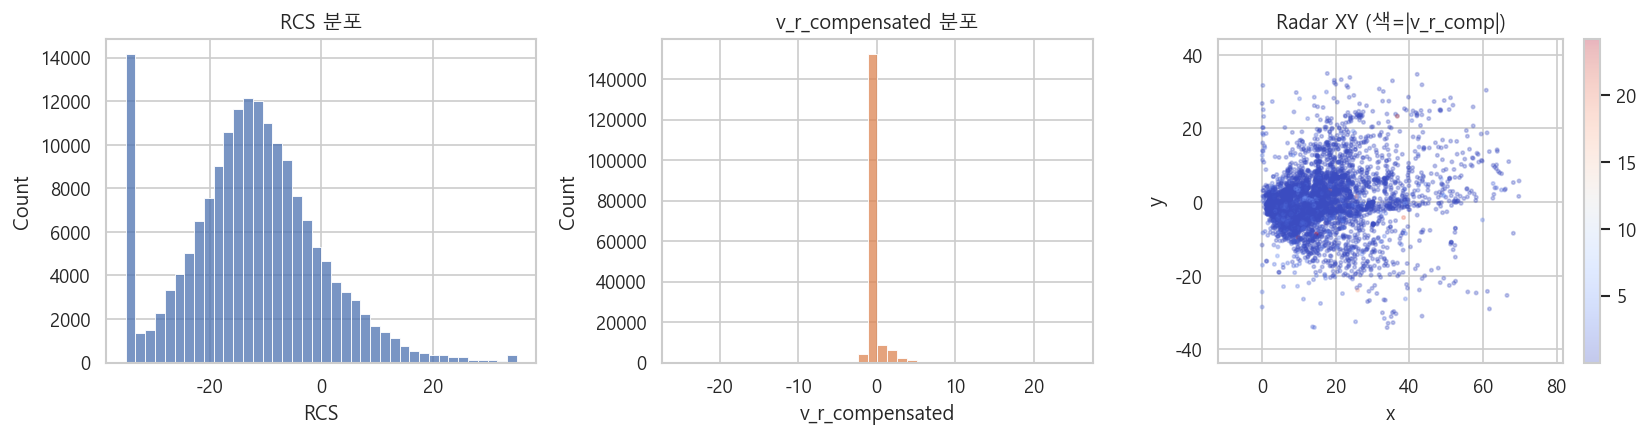

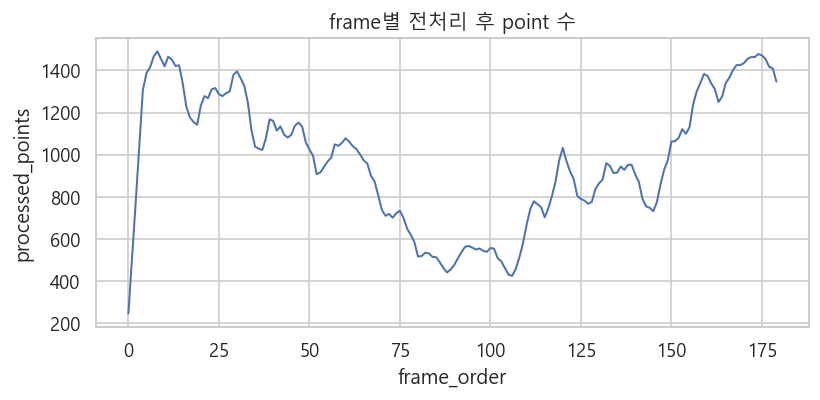

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

sns.histplot(radar_df["RCS"], bins=40, ax=axes[0], color="#4c72b0")
axes[0].set_title("RCS 분포")

sns.histplot(radar_df["v_r_compensated"], bins=40, ax=axes[1], color="#dd8452")
axes[1].set_title("v_r_compensated 분포")

sample_xy = radar_df.sample(min(5000, len(radar_df)), random_state=SEED)
sc = axes[2].scatter(sample_xy["x"], sample_xy["y"], c=sample_xy["abs_vr_comp"], s=4, alpha=0.3, cmap="coolwarm")
axes[2].set_title("Radar XY (색=|v_r_comp|)")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].axis("equal")
plt.colorbar(sc, ax=axes[2])

plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(7, 3.5))
ax2.plot(frame_summary["frame_order"], frame_summary["processed_points"], lw=1.2)
ax2.set_title("frame별 전처리 후 point 수")
ax2.set_xlabel("frame_order")
ax2.set_ylabel("processed_points")
plt.tight_layout()
plt.show()

## 3. Step 2 — Cluster Proposal 생성 (DBSCAN vs HDBSCAN)

- baseline: DBSCAN
- advanced: HDBSCAN (환경 미지원 시 자동 생략)

목표는 point-level 분류가 아니라, **안정적인 cluster candidate 생성**입니다.

In [5]:
def cluster_points_one_frame(frame_pts: pd.DataFrame, method: str = "dbscan") -> tuple[np.ndarray, dict[str, float]]:
    if frame_pts.empty:
        return np.zeros((0,), dtype=np.int32), {"noise_ratio": 1.0}

    x = frame_pts[["x", "y", "v_r_compensated"]].to_numpy(dtype=np.float32)
    x_scaled = StandardScaler().fit_transform(x)

    if method == "hdbscan" and HDBSCAN_OK:
        clusterer = hdbscan.HDBSCAN(min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE, min_samples=5)
        labels = clusterer.fit_predict(x_scaled)
        persistence_mean = float(np.mean(clusterer.cluster_persistence_)) if len(getattr(clusterer, "cluster_persistence_", [])) > 0 else np.nan
    else:
        clusterer = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES)
        labels = clusterer.fit_predict(x_scaled)
        persistence_mean = np.nan

    noise_ratio = float(np.mean(labels < 0)) if len(labels) > 0 else 1.0
    meta = {"noise_ratio": noise_ratio, "persistence_mean": persistence_mean}
    return labels.astype(np.int32), meta


def build_cluster_tables(radar_df_local: pd.DataFrame, methods: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    cluster_rows = []
    frame_quality_rows = []

    for method in methods:
        for frame_id, grp in radar_df_local.groupby("frame_id"):
            labels, meta = cluster_points_one_frame(grp, method=method)
            if labels.shape[0] != grp.shape[0]:
                continue

            tmp = grp.copy().reset_index(drop=True)
            tmp["cluster_id"] = labels

            frame_quality_rows.append(
                {
                    "algorithm": method,
                    "frame_id": frame_id,
                    "frame_order": int(tmp["frame_order"].iloc[0]),
                    "noise_ratio": float(meta["noise_ratio"]),
                    "persistence_mean": float(meta["persistence_mean"]) if np.isfinite(meta["persistence_mean"]) else np.nan,
                    "n_clusters": int(tmp.loc[tmp["cluster_id"] >= 0, "cluster_id"].nunique()),
                    "n_points": int(len(tmp)),
                }
            )

            for cid, cgrp in tmp.groupby("cluster_id"):
                if int(cid) < 0:
                    continue
                cx, cy, cz = cgrp[["x", "y", "z"]].mean().values
                spread_xy = float(np.sqrt(cgrp[["x", "y"]].var(ddof=0).sum()))
                n_points = int(len(cgrp))
                density_proxy = float(n_points / max(spread_xy + 1e-3, 1e-3))

                cluster_rows.append(
                    {
                        "algorithm": method,
                        "frame_id": frame_id,
                        "frame_order": int(cgrp["frame_order"].iloc[0]),
                        "cluster_id": int(cid),
                        "cluster_uid": f"{method}:{frame_id}:{int(cid)}",
                        "n_points": n_points,
                        "cx": float(cx),
                        "cy": float(cy),
                        "cz": float(cz),
                        "range_xy": float(np.hypot(cx, cy)),
                        "spread_xy": spread_xy,
                        "density_proxy": density_proxy,
                        "mean_rcs": float(cgrp["RCS"].mean()),
                        "rcs_std": float(cgrp["RCS"].std(ddof=0)),
                        "mean_vr_comp": float(cgrp["v_r_compensated"].mean()),
                        "abs_vr_comp": float(cgrp["v_r_compensated"].abs().mean()),
                        "vr_comp_std": float(cgrp["v_r_compensated"].std(ddof=0)),
                        "z_std": float(cgrp["z"].std(ddof=0)),
                        "time_mean": float(cgrp["time"].mean()),
                    }
                )

    cluster_df_local = pd.DataFrame(cluster_rows)
    frame_quality_df_local = pd.DataFrame(frame_quality_rows)
    return cluster_df_local, frame_quality_df_local


methods = ["dbscan"] + (["hdbscan"] if HDBSCAN_OK else [])
cluster_df_all, cluster_quality = build_cluster_tables(radar_df, methods)

if cluster_df_all.empty:
    raise RuntimeError("클러스터 생성 결과가 비어 있습니다. DBSCAN/HDBSCAN 파라미터 점검 필요")

print("cluster_df_all shape:", cluster_df_all.shape)
display(cluster_df_all.head())

# DBSCAN vs HDBSCAN 비교표 (실제로 HDBSCAN이 없으면 dbscan 행만 생성)
cmp_rows = []
for alg in cluster_df_all["algorithm"].unique():
    sub = cluster_df_all[cluster_df_all["algorithm"] == alg]
    fq = cluster_quality[cluster_quality["algorithm"] == alg]
    cmp_rows.append(
        {
            "algorithm": alg,
            "total_clusters": int(len(sub)),
            "mean_cluster_size": float(sub["n_points"].mean()),
            "mean_spread_xy": float(sub["spread_xy"].mean()),
            "mean_noise_ratio": float(fq["noise_ratio"].mean()),
            "mean_n_clusters_per_frame": float(fq["n_clusters"].mean()),
            "persistence_mean": float(fq["persistence_mean"].mean()) if "persistence_mean" in fq.columns else np.nan,
        }
    )
cluster_compare_df = pd.DataFrame(cmp_rows)


def cluster_algo_quality_score(row: pd.Series) -> float:
    # 낮은 noise, 적당한 클러스터 수/프레임, 과도하게 큰 spread 패널티
    return float(
        -row["mean_noise_ratio"]
        + 0.04 * np.clip(row["mean_n_clusters_per_frame"], 0.0, 25.0)
        - 0.0012 * row["mean_spread_xy"]
    )


cluster_compare_df["cluster_quality_score"] = cluster_compare_df.apply(cluster_algo_quality_score, axis=1)
print("\n[DBSCAN vs HDBSCAN] 클러스터 비교")
display(cluster_compare_df.sort_values("cluster_quality_score", ascending=False))

quality_summary = cluster_quality.groupby("algorithm")[["noise_ratio", "n_clusters", "n_points", "persistence_mean"]].mean(numeric_only=True)
print("\n[프레임 단위 평균 품질]")
display(quality_summary)

cluster_df_all shape: (285, 19)


,algorithm,frame_id,frame_order,cluster_id,cluster_uid,n_points,cx,cy,cz,range_xy,spread_xy,density_proxy,mean_rcs,rcs_std,mean_vr_comp,abs_vr_comp,vr_comp_std,z_std,time_mean
0,dbscan,00000,0,0,dbscan:00000:0,244,16.951839,-0.775082,0.022731,16.969549,13.273383,18.381268,-8.848340,11.344945,0.632152,0.724152,1.032872,1.362102,0.000000
1,dbscan,00001,1,0,dbscan:00001:0,501,18.423080,-1.172880,0.073243,18.460377,14.731495,34.006460,-9.613914,11.317024,0.636298,0.710023,1.054204,1.504609,-0.491018
2,dbscan,00002,2,0,dbscan:00002:0,763,18.799809,-1.255056,0.009484,18.841656,14.906321,51.182907,-9.545925,11.059464,0.600482,0.673638,1.041192,1.501106,-0.979030
3,dbscan,00003,3,0,dbscan:00003:0,1032,18.662483,-1.373888,0.007598,18.712986,14.998653,68.801590,-9.561199,11.158799,0.603820,0.681323,1.039255,1.511677,-1.464147
4,dbscan,00004,4,0,dbscan:00004:0,1297,18.817604,-1.612512,0.019082,18.886568,15.341944,84.533974,-9.525822,11.183929,0.574892,0.652008,1.014984,1.534633,-1.959908



[알고리즘별 cluster quality] dbscan/hdbscan 비교


,noise_ratio,n_clusters,n_points,persistence_mean
algorithm,,,,
dbscan,0.013177,1.583333,976.127778,NaN


SELECTED_CLUSTER_ALGO: dbscan
selected cluster rows: 285


,algorithm,noise_ratio,n_clusters,score
0,dbscan,0.013177,1.583333,0.002657


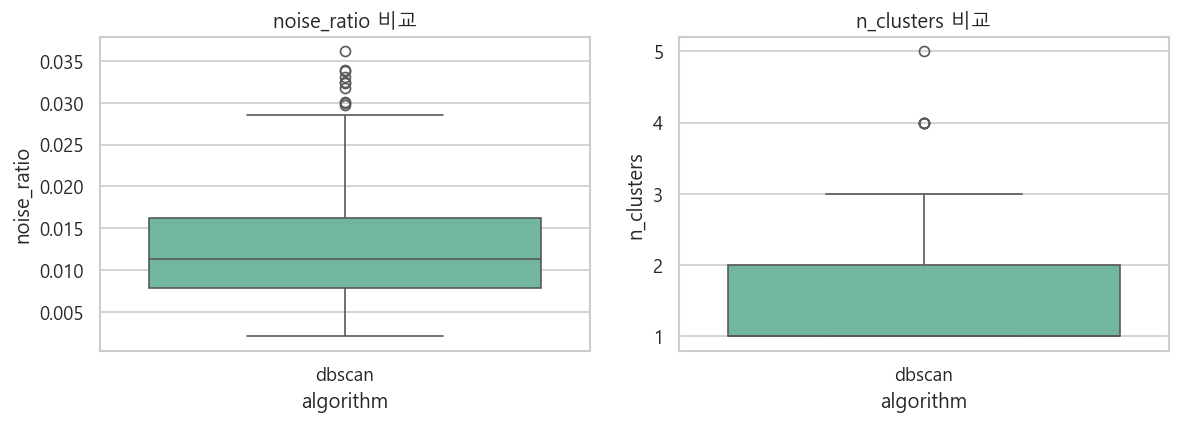

In [6]:
# cluster_quality_score 기반 최종 선택 (noise·클러스터 수·spread 균형)
SELECTED_CLUSTER_ALGO = cluster_compare_df.sort_values("cluster_quality_score", ascending=False).iloc[0]["algorithm"]

cluster_df = cluster_df_all[cluster_df_all["algorithm"] == SELECTED_CLUSTER_ALGO].copy().reset_index(drop=True)
print("SELECTED_CLUSTER_ALGO:", SELECTED_CLUSTER_ALGO, "| rows:", len(cluster_df))

display(cluster_compare_df[["algorithm", "cluster_quality_score", "mean_noise_ratio", "total_clusters", "mean_spread_xy"]])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.7))
sns.boxplot(data=cluster_quality, x="algorithm", y="noise_ratio", ax=axes[0], palette="Set2")
axes[0].set_title("noise_ratio 비교")
sns.boxplot(data=cluster_quality, x="algorithm", y="n_clusters", ax=axes[1], palette="Set2")
axes[1].set_title("n_clusters 비교")
plt.tight_layout()
plt.show()

## 4. Step 3 — LiDAR corroboration (보조 검증)

LiDAR는 정답 생성기가 아니라 **보조 검증기**로만 사용합니다.

출력 컬럼:
- `lidar_min_dist`
- `lidar_local_density`
- `lidar_verified`
- `lidar_corroboration_score`

In [7]:
frame_by_id = {fr["frame_id"]: fr for fr in frames}

# 다반경 + footprint 기반 LiDAR corroboration (v2)
cluster_df = v2.attach_lidar_corroboration_v2(cluster_df, frame_by_id, ROI, r1=1.5, r2=2.5, r3=4.0, verify_radius=2.2)
cluster_df["lidar_local_density"] = cluster_df["lidar_local_density_r2"]

print("cluster_df + lidar (v2) shape:", cluster_df.shape)
display(
    cluster_df[
        [
            "frame_id",
            "cluster_id",
            "lidar_min_dist",
            "lidar_local_density_r1",
            "lidar_local_density_r2",
            "lidar_local_density_r3",
            "lidar_extent_density",
            "lidar_verified",
            "lidar_corroboration_score",
        ]
    ].head()
)

print("\nLiDAR corroboration 요약")
display(
    cluster_df[
        [
            "lidar_min_dist",
            "lidar_local_density_r1",
            "lidar_local_density_r2",
            "lidar_local_density_r3",
            "lidar_extent_density",
            "lidar_corroboration_score",
        ]
    ]
    .describe()
    .T
)

cluster_df + lidar shape: (285, 23)


,frame_id,cluster_id,lidar_min_dist,lidar_local_density,lidar_verified,lidar_corroboration_score
0,00000,0,2.537285,0.0,0,0.403983
1,00001,0,2.652259,0.0,0,0.390570
2,00002,0,2.553510,0.0,0,0.402090
3,00003,0,2.458600,0.0,0,0.413163
4,00004,0,2.718554,0.0,0,0.382835



LiDAR corroboration 요약


,count,mean,std,min,25%,50%,75%,max
lidar_min_dist,285.0,1.591955,3.601717,0.007808,0.114879,0.421960,1.328243,29.849283
lidar_local_density,285.0,0.009925,0.015710,0.000000,0.000505,0.003378,0.014333,0.090859
lidar_corroboration_score,285.0,0.581241,0.193910,0.000000,0.547753,0.655815,0.702600,0.802353


## 5. Step 4 — Temporal Tracking (baseline vs improved)

- baseline: centroid nearest-neighbor
- improved: gated assignment + Hungarian (가능 시)

track feature 출력:
- `track_id`, `track_len`, `avg_speed`, `heading_change`, `approach_score`, `temporal_stability_score`, `cluster_persistence`

In [8]:
def _assign_greedy(cost_mat: np.ndarray, gate: float) -> list[tuple[int, int]]:
    if cost_mat.size == 0:
        return []
    pairs = []
    used_r, used_c = set(), set()
    flat = [(i, j, cost_mat[i, j]) for i in range(cost_mat.shape[0]) for j in range(cost_mat.shape[1])]
    flat.sort(key=lambda x: x[2])
    for i, j, c in flat:
        if c > gate:
            continue
        if i in used_r or j in used_c:
            continue
        used_r.add(i)
        used_c.add(j)
        pairs.append((i, j))
    return pairs


def run_tracking(cluster_df_local: pd.DataFrame, mode: str = "baseline", gate_dist: float = TRACK_GATE_DIST, max_miss: int = 2) -> pd.DataFrame:
    work = cluster_df_local.sort_values(["frame_order", "cluster_id"]).copy().reset_index(drop=True)

    next_track_id = 0
    active: dict[int, dict[str, Any]] = {}
    obs_rows = []

    for frame_order, frame_grp in work.groupby("frame_order"):
        cur = frame_grp.copy().reset_index(drop=True)
        cur_pos = cur[["cx", "cy"]].to_numpy(dtype=np.float32)
        cur_uid = cur["cluster_uid"].tolist()
        cur_range = cur["range_xy"].to_numpy(dtype=np.float32)

        active_ids = list(active.keys())
        assigned_pairs: list[tuple[int, int]] = []

        if active_ids and len(cur_pos) > 0:
            pred_pos = []
            for tid in active_ids:
                tr = active[tid]
                if mode == "improved" and tr.get("vel") is not None:
                    p = tr["pos"] + tr["vel"] * RADAR_DT_SEC
                else:
                    p = tr["pos"]
                pred_pos.append(p)
            pred_pos = np.asarray(pred_pos)

            cost = np.linalg.norm(pred_pos[:, None, :] - cur_pos[None, :, :], axis=2)

            if mode == "improved" and SCIPY_OK:
                ri, ci = linear_sum_assignment(cost)
                assigned_pairs = [(int(r), int(c)) for r, c in zip(ri, ci) if cost[r, c] <= gate_dist]
            else:
                assigned_pairs = _assign_greedy(cost, gate_dist)

        matched_active = set()
        matched_cur = set()

        for r, c in assigned_pairs:
            tid = active_ids[r]
            matched_active.add(tid)
            matched_cur.add(c)

            tr = active[tid]
            prev_pos = tr["pos"]
            new_pos = cur_pos[c]
            vel = (new_pos - prev_pos) / max(RADAR_DT_SEC, 1e-6)
            speed = float(np.linalg.norm(vel))
            heading = float(math.atan2(vel[1], vel[0])) if speed > 1e-6 else float(tr.get("heading", 0.0))
            approach_delta = float(tr.get("last_range", cur_range[c]) - cur_range[c])

            tr["pos"] = new_pos
            tr["vel"] = vel
            tr["last_range"] = float(cur_range[c])
            tr["last_frame"] = int(frame_order)
            tr["miss"] = 0
            tr.setdefault("speeds", []).append(speed)
            tr.setdefault("headings", []).append(heading)
            tr.setdefault("approach_deltas", []).append(approach_delta)
            tr.setdefault("uids", []).append(cur_uid[c])

            obs_rows.append(
                {
                    "cluster_uid": cur_uid[c],
                    "frame_order": int(frame_order),
                    "track_id": int(tid),
                    "obs_speed": speed,
                    "obs_heading": heading,
                    "approach_delta": approach_delta,
                }
            )

        # new tracks
        for c in range(len(cur_pos)):
            if c in matched_cur:
                continue
            tid = next_track_id
            next_track_id += 1
            active[tid] = {
                "pos": cur_pos[c],
                "vel": np.array([0.0, 0.0], dtype=np.float32),
                "last_range": float(cur_range[c]),
                "last_frame": int(frame_order),
                "miss": 0,
                "speeds": [0.0],
                "headings": [0.0],
                "approach_deltas": [0.0],
                "uids": [cur_uid[c]],
            }
            obs_rows.append(
                {
                    "cluster_uid": cur_uid[c],
                    "frame_order": int(frame_order),
                    "track_id": int(tid),
                    "obs_speed": 0.0,
                    "obs_heading": 0.0,
                    "approach_delta": 0.0,
                }
            )

        # miss update
        for tid in list(active.keys()):
            if tid in matched_active:
                continue
            active[tid]["miss"] += 1
            if active[tid]["miss"] > max_miss:
                del active[tid]

    obs_df = pd.DataFrame(obs_rows)
    if obs_df.empty:
        return pd.DataFrame(columns=["cluster_uid", "track_id"])

    # track-level summary
    trows = []
    for tid, g in obs_df.groupby("track_id"):
        g = g.sort_values("frame_order")
        speeds = g["obs_speed"].to_numpy()
        heads = g["obs_heading"].to_numpy()
        apps = g["approach_delta"].to_numpy()

        heading_change = float(np.mean(np.abs(np.diff(heads)))) if len(heads) > 1 else 0.0
        approach_score = float(np.mean(np.clip(apps, 0.0, None)))
        temporal_stability = float(np.exp(-np.std(speeds))) * min(len(g) / 6.0, 1.0)

        trows.append(
            {
                "track_id": int(tid),
                "track_len": int(len(g)),
                "avg_speed": float(np.mean(speeds)),
                "heading_change": heading_change,
                "approach_score": approach_score,
                "temporal_stability_score": temporal_stability,
                "cluster_persistence": float(len(g) / max(cluster_df_local["frame_order"].nunique(), 1)),
            }
        )

    track_summary = pd.DataFrame(trows)
    out = obs_df.merge(track_summary, on="track_id", how="left")
    return out


track_obs_baseline = run_tracking(cluster_df, mode="baseline", gate_dist=TRACK_GATE_DIST, max_miss=1)
track_obs_improved = run_tracking(cluster_df, mode="improved", gate_dist=TRACK_GATE_DIST, max_miss=2)

print("baseline track obs:", track_obs_baseline.shape, "| improved:", track_obs_improved.shape)

def _track_quality_extended(obs: pd.DataFrame, tag: str) -> dict[str, float]:
    if obs.empty:
        return {"mode": tag, "n_tracks": 0}
    tlens = obs.groupby("track_id").size()
    frag = float((tlens == 1).mean())  # 단발성 track 비율(단편화 proxy)
    return {
        "mode": tag,
        "n_tracks": int(obs["track_id"].nunique()),
        "mean_track_len": float(tlens.mean()),
        "median_track_len": float(tlens.median()),
        "track_fragmentation_rate": frag,
        "mean_speed": float(obs["obs_speed"].mean()),
        "mean_heading_change": float(obs["heading_change"].mean()),
        "mean_temporal_stability": float(obs["temporal_stability_score"].mean()),
        "mean_approach_score": float(obs["approach_score"].mean()),
    }

track_quality_df = pd.DataFrame([
    _track_quality_extended(track_obs_baseline, "baseline"),
    _track_quality_extended(track_obs_improved, "improved"),
])
print("[baseline vs improved tracking 확장 비교]")
display(track_quality_df)

TRACK_MODE = "improved" if (not track_obs_improved.empty) else "baseline"
track_obs = track_obs_improved if TRACK_MODE == "improved" else track_obs_baseline
print("selected TRACK_MODE:", TRACK_MODE)

baseline track obs: (285, 12) | improved: (285, 12)


,mode,n_tracks,mean_track_len,mean_temporal_stability,mean_approach_score
0,baseline,49,5.816327,0.029267,0.175023
1,improved,53,5.377358,0.036832,0.153132


selected TRACK_MODE: improved


In [9]:
cluster_df = cluster_df.merge(
    track_obs[
        [
            "cluster_uid",
            "track_id",
            "obs_speed",
            "obs_heading",
            "approach_delta",
            "track_len",
            "avg_speed",
            "heading_change",
            "approach_score",
            "temporal_stability_score",
            "cluster_persistence",
        ]
    ],
    on="cluster_uid",
    how="left",
)

# tracking 미매칭 값 보정
for col, fillv in {
    "track_id": -1,
    "obs_speed": 0.0,
    "obs_heading": 0.0,
    "approach_delta": 0.0,
    "track_len": 1,
    "avg_speed": 0.0,
    "heading_change": 0.0,
    "approach_score": 0.0,
    "temporal_stability_score": 0.0,
    "cluster_persistence": 0.0,
}.items():
    cluster_df[col] = cluster_df[col].fillna(fillv)

print("cluster_df with tracking shape:", cluster_df.shape)
display(cluster_df.head())

cluster_df with tracking shape: (285, 33)


,algorithm,frame_id,frame_order,cluster_id,cluster_uid,n_points,cx,cy,cz,range_xy,...,track_id,obs_speed,obs_heading,approach_delta,track_len,avg_speed,heading_change,approach_score,temporal_stability_score,cluster_persistence
0,dbscan,00000,0,0,dbscan:00000:0,244,16.951839,-0.775082,0.022731,16.969549,...,0,0.000000,0.000000,0.000000,39,5.435709,1.841098,0.240268,0.018243,0.216667
1,dbscan,00001,1,0,dbscan:00001:0,501,18.423080,-1.172880,0.073243,18.460377,...,0,19.812925,-0.264068,-1.490828,39,5.435709,1.841098,0.240268,0.018243,0.216667
2,dbscan,00002,2,0,dbscan:00002:0,763,18.799809,-1.255056,0.009484,18.841656,...,0,5.012625,-0.214768,-0.381279,39,5.435709,1.841098,0.240268,0.018243,0.216667
3,dbscan,00003,3,0,dbscan:00003:0,1032,18.662483,-1.373888,0.007598,18.712986,...,0,2.360822,-2.428266,0.128670,39,5.435709,1.841098,0.240268,0.018243,0.216667
4,dbscan,00004,4,0,dbscan:00004:0,1297,18.817604,-1.612512,0.019082,18.886568,...,0,3.699955,-0.994376,-0.173582,39,5.435709,1.841098,0.240268,0.018243,0.216667


## 6. Step 5 — Rule-based Risk Scoring (운영 baseline)

Rule-based는 운영 기준선이며, 아래 요소를 결합합니다.
- TTC
- 거리/접근성
- 상대속도
- temporal approach / persistence
- LiDAR corroboration

출력:
- `risk_score_rule`
- `risk_label_rule`

rule label 분포


,count
risk_label_rule,
low,259
medium,26
high,0


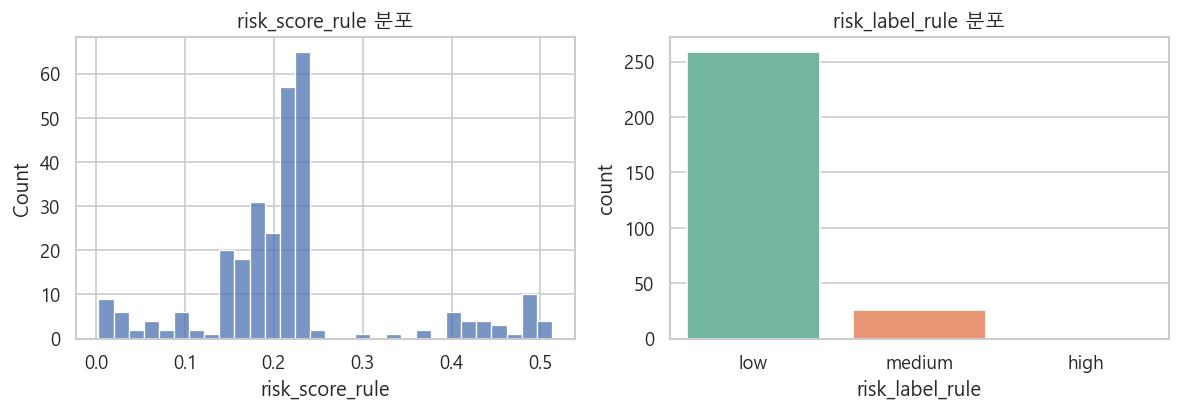

In [10]:
# Rule-based: 연속 score + hybrid quantile 게이트 라벨 (high=0 방지)
RISK_LABEL_MODE = os.environ.get("RISK_LABEL_MODE", "hybrid_quantile")  # hybrid_quantile | fixed

risk_df = v2.assign_hybrid_risk_labels(cluster_df.copy(), mode=RISK_LABEL_MODE)
risk_df["risk_label_ml_target"] = risk_df["risk_label_rule"].astype(str)

print("rule label 분포 | mode =", RISK_LABEL_MODE)
label_counts = risk_df["risk_label_rule"].value_counts().reindex(["low", "medium", "high"]).fillna(0).astype(int)
display(label_counts.to_frame("count"))

# 분포·분위수
qs = [0.5, 0.7, 0.8, 0.9, 0.95, 0.98]
quant_tbl = pd.DataFrame({"quantile": qs, "risk_score_rule": [risk_df["risk_score_rule"].quantile(q) for q in qs]})
print("risk_score_rule 분위수")
display(quant_tbl.T)

corr_cols = [c for c in ["track_len", "approach_score", "ttc", "range_xy", "risk_score_rule"] if c in risk_df.columns]
print("상관(참고)")
display(risk_df[corr_cols].corr(numeric_only=True))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
sns.histplot(risk_df["risk_score_rule"], bins=30, ax=axes[0], color="#4c72b0")
axes[0].set_title("risk_score_rule 분포")
sns.countplot(data=risk_df, x="risk_label_rule", order=["low", "medium", "high"], ax=axes[1], palette="Set2")
axes[1].set_title("risk_label_rule 분포")
plt.tight_layout()
plt.show()

print("\n[Threshold sensitivity]")
display(v2.threshold_sensitivity_table(cluster_df.copy()))

## 7. Step 6 — ML-based refinement (누설 금지)

### 설계
- Rule-based는 운영 baseline
- ML은 refinement/confidence/ranking support 용도

### 누설 금지
ML 입력에서 아래 변수는 제외:
- `ttc`
- `range_xy`
- `abs_vr_comp`

### 평가 split
- 기본: `group(frame_id)` + `time(frame_order)`
- 진단용으로만 `random` 사용 (leakage 비교 목적)

In [11]:
LABEL_ORDER = ["low", "medium", "high"]


def build_feature_sets(df: pd.DataFrame) -> dict[str, list[str]]:
    feat_A = [
        "n_points", "spread_xy", "density_proxy", "mean_rcs", "rcs_std",
        "mean_vr_comp", "vr_comp_std", "z_std", "cz",
        "track_len", "avg_speed", "heading_change", "approach_score",
        "temporal_stability_score", "cluster_persistence",
    ]
    feat_B = feat_A + [
        "lidar_verified",
        "lidar_min_dist",
        "lidar_local_density",
        "lidar_local_density_r1",
        "lidar_local_density_r2",
        "lidar_local_density_r3",
        "lidar_extent_density",
        "lidar_corroboration_score",
    ]
    feat_C = feat_B + ["ttc", "range_xy", "abs_vr_comp"]  # 진단용 leakage 포함

    out = {}
    for name, cols in {
        "A_strict_anti_leakage": feat_A,
        "B_moderate_anti_leakage": feat_B,
        "C_diagnostic_leakage": feat_C,
    }.items():
        out[name] = [c for c in cols if c in df.columns]
    return out


def split_data(df: pd.DataFrame, feature_cols: list[str], split_mode: str = "group"):
    work = df.copy().dropna(subset=["risk_label_ml_target"])
    X = work[feature_cols].replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True))
    y = work["risk_label_ml_target"].astype(str)

    if split_mode == "group":
        gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
        tr_idx, te_idx = next(gss.split(X, y, groups=work["frame_id"].astype(str)))
    elif split_mode == "time":
        uniq = work[["frame_id", "frame_order"]].drop_duplicates().sort_values("frame_order")
        n = len(uniq)
        tr_end = max(int(n * 0.70), 1)
        val_end = max(int(n * 0.85), tr_end + 1)
        tr_frames = set(uniq.iloc[:tr_end]["frame_id"].astype(str))
        te_frames = set(uniq.iloc[val_end:]["frame_id"].astype(str))
        tr_idx = np.where(work["frame_id"].astype(str).isin(tr_frames))[0]
        te_idx = np.where(work["frame_id"].astype(str).isin(te_frames))[0]
    elif split_mode == "random":
        tr_idx, te_idx = train_test_split(
            np.arange(len(work)),
            test_size=0.25,
            random_state=SEED,
            stratify=y,
        )
    else:
        raise ValueError(split_mode)

    return {
        "X_train": X.iloc[tr_idx].copy(),
        "X_test": X.iloc[te_idx].copy(),
        "y_train": y.iloc[tr_idx].copy(),
        "y_test": y.iloc[te_idx].copy(),
        "train_df": work.iloc[tr_idx].copy(),
        "test_df": work.iloc[te_idx].copy(),
    }


def build_model(model_name: str):
    m = model_name.lower()
    if m == "logistic_regression":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2500, class_weight="balanced", random_state=SEED)),
        ])
    if m == "random_forest":
        return RandomForestClassifier(
            n_estimators=320,
            max_depth=10,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=SEED,
            n_jobs=-1,
        )
    if m == "hist_gradient_boosting":
        return HistGradientBoostingClassifier(
            max_depth=8,
            learning_rate=0.06,
            max_iter=240,
            random_state=SEED,
        )
    if m == "svm_rbf":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(kernel="rbf", C=3.0, gamma="scale", class_weight="balanced", probability=True)),
        ])
    raise ValueError(model_name)


def _fit_with_weight(model, X_train, y_train):
    sw = compute_sample_weight(class_weight="balanced", y=y_train)
    try:
        model.fit(X_train, y_train, sample_weight=sw)
        return model
    except Exception:
        pass

    if isinstance(model, Pipeline):
        last = model.steps[-1][0]
        try:
            model.fit(X_train, y_train, **{f"{last}__sample_weight": sw})
            return model
        except Exception:
            pass

    model.fit(X_train, y_train)
    return model


def _risk_score_from_proba(classes: list[str], proba: np.ndarray) -> np.ndarray:
    cls_to_idx = {c: i for i, c in enumerate(classes)}
    p_low = proba[:, cls_to_idx.get("low", 0)] if "low" in cls_to_idx else np.zeros(len(proba))
    p_med = proba[:, cls_to_idx.get("medium", 0)] if "medium" in cls_to_idx else np.zeros(len(proba))
    p_high = proba[:, cls_to_idx.get("high", 0)] if "high" in cls_to_idx else np.zeros(len(proba))
    return np.clip(0.15 * p_low + 0.60 * p_med + 1.00 * p_high, 0.0, 1.0)


def run_cls_experiment(df: pd.DataFrame, feature_set_name: str, feature_cols: list[str], model_name: str, split_mode: str):
    sp = split_data(df, feature_cols, split_mode=split_mode)
    X_train, X_test = sp["X_train"], sp["X_test"]
    y_train, y_test = sp["y_train"], sp["y_test"]

    model = build_model(model_name)

    # SVM 계산량 제어
    if model_name == "svm_rbf" and len(X_train) > 9000:
        idx = np.random.default_rng(SEED).choice(len(X_train), 9000, replace=False)
        X_train = X_train.iloc[idx]
        y_train = y_train.iloc[idx]

    model = _fit_with_weight(model, X_train, y_train)

    yhat_train = model.predict(X_train)
    yhat_test = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        proba_test = model.predict_proba(X_test)
        classes = list(model.classes_)
    elif isinstance(model, Pipeline) and hasattr(model.steps[-1][1], "predict_proba"):
        proba_test = model.predict_proba(X_test)
        classes = list(model.steps[-1][1].classes_)
    else:
        classes = LABEL_ORDER
        proba_test = np.zeros((len(X_test), len(classes)))
        pred_idx = pd.Series(yhat_test).map({c: i for i, c in enumerate(classes)}).fillna(0).astype(int).to_numpy()
        proba_test[np.arange(len(X_test)), pred_idx] = 1.0

    risk_score_ml = _risk_score_from_proba(classes, proba_test)
    risk_confidence_ml = np.max(proba_test, axis=1)

    cm = confusion_matrix(y_test, yhat_test, labels=LABEL_ORDER)
    report = classification_report(y_test, yhat_test, labels=LABEL_ORDER, output_dict=True, zero_division=0)

    y_high_hard = (y_test.astype(str) == "high").astype(int).to_numpy()
    rs_train = sp["train_df"]["risk_score_rule"].to_numpy(dtype=np.float64)
    rs_test = sp["test_df"]["risk_score_rule"].to_numpy(dtype=np.float64)
    thr10 = float(np.quantile(rs_train, 0.90))
    thr15 = float(np.quantile(rs_train, 0.85))
    soft10 = (rs_test >= thr10).astype(int)
    soft15 = (rs_test >= thr15).astype(int)
    rmetrics = v2.ranking_metrics_extended(y_high_hard, risk_score_ml, soft_positive=soft10, ks=[5, 10, 20])
    r15 = v2.ranking_metrics_extended(y_high_hard, risk_score_ml, soft_positive=soft15, ks=[5, 10, 20])
    for k, v in r15.items():
        rmetrics[k + "_softq15"] = v
    sp_r, kd_r = v2.spearman_kendall(risk_score_ml, rs_test)
    rmetrics["spearman_ml_vs_rule_score"] = sp_r
    rmetrics["kendall_ml_vs_rule_score"] = kd_r


    out = {
        "feature_set": feature_set_name,
        "model_name": model_name,
        "split_mode": split_mode,
        "train_accuracy": float(accuracy_score(y_train, yhat_train)),
        "test_accuracy": float(accuracy_score(y_test, yhat_test)),
        "test_macro_f1": float(f1_score(y_test, yhat_test, average="macro", zero_division=0)),
        "test_weighted_f1": float(f1_score(y_test, yhat_test, average="weighted", zero_division=0)),
        "high_recall": float(report.get("high", {}).get("recall", np.nan)),
        "medium_recall": float(report.get("medium", {}).get("recall", np.nan)),
        "classification_report": report,
        "confusion_matrix": cm,
        "model": model,
        "feature_cols": feature_cols,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred_test": yhat_test,
        "risk_score_ml_test": risk_score_ml,
        "risk_confidence_ml_test": risk_confidence_ml,
    }
    out.update(rmetrics)
    return out


def summarize_results(results: list[dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for r in results:
        rows.append(
            {
                "feature_set": r["feature_set"],
                "split_mode": r["split_mode"],
                "model_name": r["model_name"],
                "train_acc": round(r["train_accuracy"], 4),
                "test_acc": round(r["test_accuracy"], 4),
                "macro_f1": round(r["test_macro_f1"], 4),
                "weighted_f1": round(r["test_weighted_f1"], 4),
                "high_recall": round(r["high_recall"], 4),
                "medium_recall": round(r["medium_recall"], 4),
                "precision@10_hard": round(r.get("precision@10_hard", np.nan), 4),
                "recall@10_hard": round(r.get("recall@10_hard", np.nan), 4),
                "ap_soft": round(r.get("average_precision_soft", np.nan), 4),
                "ndcg@10_soft": round(r.get("ndcg@10_soft", np.nan), 4),
                "spearman_ml_rule": round(r.get("spearman_ml_vs_rule_score", np.nan), 4),
                "overfit_gap": round(r["train_accuracy"] - r["test_accuracy"], 4),
            }
        )
    return pd.DataFrame(rows).sort_values(["macro_f1", "high_recall"], ascending=[False, False]).reset_index(drop=True)


feature_sets = build_feature_sets(risk_df)
feature_table = pd.DataFrame(
    [{"feature_set": k, "n_features": len(v), "features": ", ".join(v)} for k, v in feature_sets.items()]
)
print("Feature set 구성")
display(feature_table)

Feature set 구성


,feature_set,n_features,features
0,A_strict_anti_leakage,15,"n_points, spread_xy, density_proxy, mean_rcs, ..."
1,B_moderate_anti_leakage,19,"n_points, spread_xy, density_proxy, mean_rcs, ..."
2,C_diagnostic_leakage,22,"n_points, spread_xy, density_proxy, mean_rcs, ..."


## 8. Step 7 — 평가 실험 (group/time 중심 + leakage 진단 비교)

- 기본 평가는 group/time split
- random split은 leakage 진단 목적에서만 유지

In [12]:
EXPERIMENT_PLAN = [
    # leakage 진단
    ("C_diagnostic_leakage", "random", "logistic_regression", "진단: 누설+랜덤 선형 baseline"),
    ("C_diagnostic_leakage", "random", "random_forest", "진단: 누설+랜덤 트리 baseline"),
    ("C_diagnostic_leakage", "group", "random_forest", "진단: 누설 고정, split만 그룹으로 변경"),

    # honest 평가 (핵심)
    ("A_strict_anti_leakage", "group", "logistic_regression", "정직평가: 단순 선형"),
    ("A_strict_anti_leakage", "group", "random_forest", "정직평가: baseline 비선형"),
    ("A_strict_anti_leakage", "group", "hist_gradient_boosting", "정직평가: 고급 boosting"),
    ("A_strict_anti_leakage", "group", "svm_rbf", "정직평가: 고급 결정경계"),
    ("A_strict_anti_leakage", "time", "hist_gradient_boosting", "시간 일반화"),
    ("A_strict_anti_leakage", "time", "random_forest", "시간 일반화 baseline"),

    # moderate anti-leakage (LiDAR 보조 feature 포함)
    ("B_moderate_anti_leakage", "group", "random_forest", "LiDAR corroboration 보조"),
    ("B_moderate_anti_leakage", "group", "hist_gradient_boosting", "LiDAR 보조 + 고급모델"),
    ("B_moderate_anti_leakage", "time", "svm_rbf", "LiDAR 보조 + 시간 일반화"),
]

plan_df = pd.DataFrame(EXPERIMENT_PLAN, columns=["feature_set", "split_mode", "model_name", "목적"])
display(plan_df)

results = []
for fs, sp, md, _ in EXPERIMENT_PLAN:
    print(f"run: {fs} | {sp} | {md}")
    results.append(run_cls_experiment(risk_df, fs, feature_sets[fs], md, sp))

results_table = summarize_results(results)
print("\n실험 결과 요약")
display(results_table)

pivot_macro = results_table.pivot_table(index=["feature_set", "split_mode"], columns="model_name", values="macro_f1")
print("macro F1 pivot")
display(pivot_macro)

# leakage vs honest 정량 비교
leak_random = results_table[(results_table["feature_set"] == "C_diagnostic_leakage") & (results_table["split_mode"] == "random")]
honest = results_table[(results_table["feature_set"].isin(["A_strict_anti_leakage", "B_moderate_anti_leakage"])) & (results_table["split_mode"].isin(["group", "time"]))]

diag_compare = pd.DataFrame({
    "leak_random_acc_mean": [leak_random["test_acc"].mean()],
    "leak_random_macro_f1_mean": [leak_random["macro_f1"].mean()],
    "honest_acc_mean": [honest["test_acc"].mean()],
    "honest_macro_f1_mean": [honest["macro_f1"].mean()],
    "honest_ranking_ap_soft_mean": [honest["ap_soft"].mean()],
    "honest_high_recall_mean": [honest["high_recall"].mean()],
    "acc_gap": [leak_random["test_acc"].mean() - honest["test_acc"].mean()],
    "macro_f1_gap": [leak_random["macro_f1"].mean() - honest["macro_f1"].mean()],
})
print("\nLeakage vs Honest 비교")
display(diag_compare.round(4))

,feature_set,split_mode,model_name,목적
0,C_diagnostic_leakage,random,logistic_regression,진단: 누설+랜덤 선형 baseline
1,C_diagnostic_leakage,random,random_forest,진단: 누설+랜덤 트리 baseline
2,C_diagnostic_leakage,group,random_forest,"진단: 누설 고정, split만 그룹으로 변경"
3,A_strict_anti_leakage,group,logistic_regression,정직평가: 단순 선형
4,A_strict_anti_leakage,group,random_forest,정직평가: baseline 비선형
5,A_strict_anti_leakage,group,hist_gradient_boosting,정직평가: 고급 boosting
6,A_strict_anti_leakage,group,svm_rbf,정직평가: 고급 결정경계
7,A_strict_anti_leakage,time,hist_gradient_boosting,시간 일반화
8,A_strict_anti_leakage,time,random_forest,시간 일반화 baseline
9,B_moderate_anti_leakage,group,random_forest,LiDAR corroboration 보조


run: C_diagnostic_leakage | random | logistic_regression
run: C_diagnostic_leakage | random | random_forest
run: C_diagnostic_leakage | group | random_forest
run: A_strict_anti_leakage | group | logistic_regression
run: A_strict_anti_leakage | group | random_forest
run: A_strict_anti_leakage | group | hist_gradient_boosting
run: A_strict_anti_leakage | group | svm_rbf
run: A_strict_anti_leakage | time | hist_gradient_boosting
run: A_strict_anti_leakage | time | random_forest
run: B_moderate_anti_leakage | group | random_forest
run: B_moderate_anti_leakage | group | hist_gradient_boosting
run: B_moderate_anti_leakage | time | svm_rbf

실험 결과 요약


,feature_set,split_mode,model_name,train_acc,test_acc,macro_f1,weighted_f1,high_recall,medium_recall,precision@10,recall@10,overfit_gap
0,C_diagnostic_leakage,random,random_forest,1.0000,1.0000,1.0000,1.0000,0.0,1.0,0.0,0.0,0.0000
1,C_diagnostic_leakage,group,random_forest,1.0000,1.0000,1.0000,1.0000,0.0,1.0,0.0,0.0,0.0000
2,A_strict_anti_leakage,group,svm_rbf,0.9954,1.0000,1.0000,1.0000,0.0,1.0,0.0,0.0,-0.0046
3,C_diagnostic_leakage,random,logistic_regression,0.9906,0.9861,0.9628,0.9865,0.0,1.0,0.0,0.0,0.0045
4,B_moderate_anti_leakage,group,random_forest,0.9954,0.9853,0.9247,0.9863,0.0,1.0,0.0,0.0,0.0101
5,A_strict_anti_leakage,group,logistic_regression,0.9862,0.9706,0.8672,0.9740,0.0,1.0,0.0,0.0,0.0156
6,A_strict_anti_leakage,group,random_forest,1.0000,0.9706,0.8672,0.9740,0.0,1.0,0.0,0.0,0.0294
7,A_strict_anti_leakage,group,hist_gradient_boosting,1.0000,0.9706,0.8672,0.9740,0.0,1.0,0.0,0.0,0.0294
8,B_moderate_anti_leakage,group,hist_gradient_boosting,1.0000,0.9706,0.8672,0.9740,0.0,1.0,0.0,0.0,0.0294
9,A_strict_anti_leakage,time,hist_gradient_boosting,1.0000,0.7627,0.4327,0.6600,0.0,0.0,0.0,0.0,0.2373


macro F1 pivot


model_name                          hist_gradient_boosting  \
feature_set             split_mode                           
A_strict_anti_leakage   group                       0.8672   
                        time                        0.4327   
B_moderate_anti_leakage group                       0.8672   
                        time                           NaN   
C_diagnostic_leakage    group                          NaN   
                        random                         NaN   

model_name                          logistic_regression  random_forest  \
feature_set             split_mode                                       
A_strict_anti_leakage   group                    0.8672         0.8672   
                        time                        NaN         0.4327   
B_moderate_anti_leakage group                       NaN         0.9247   
                        time                        NaN            NaN   
C_diagnostic_leakage    group                       NaN         1.0000   
                        random                   0.9628         1.0000   

model_name                          svm_rbf  
feature_set             split_mode           
A_strict_anti_leakage   group        1.0000  
                        time            NaN  
B_moderate_anti_leakage group           NaN  
                        time         0.4327  
C_diagnostic_leakage    group           NaN  
                        random          NaN


Leakage vs Honest 비교


,leak_random_acc_mean,leak_random_macro_f1_mean,honest_acc_mean,honest_macro_f1_mean,acc_gap,macro_f1_gap
0,0.993,0.9814,0.9062,0.7435,0.0868,0.2379


## 9. Best model 선정 (accuracy 금지 기준) + 상세 해석

선정 우선순위:
1. anti-leakage
2. group/time split
3. macro F1
4. high/medium recall
5. overfit gap
6. 해석 가능성

BEST (선정 기준 기반)
{'feature_set': 'A_strict_anti_leakage', 'split_mode': 'group', 'model_name': 'svm_rbf', 'test_acc': 1.0, 'macro_f1': 1.0, 'high_recall': 0.0, 'medium_recall': 1.0}


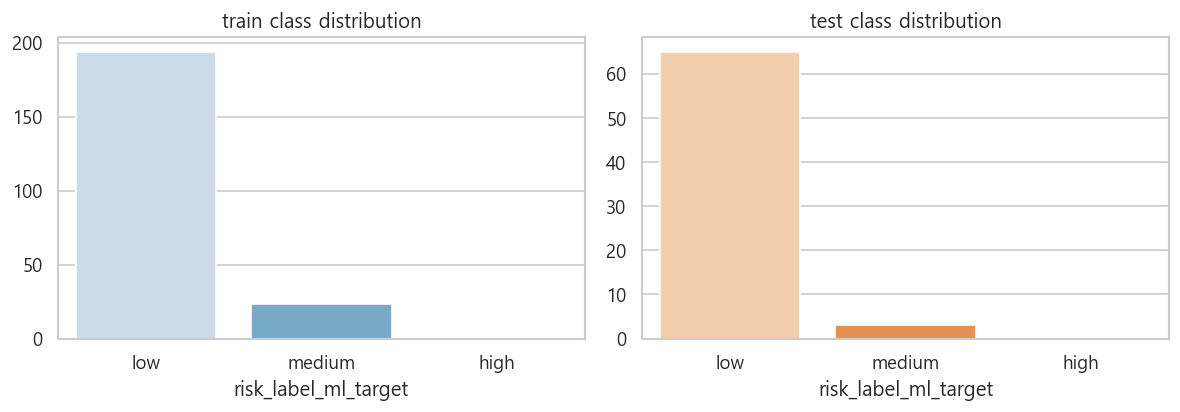

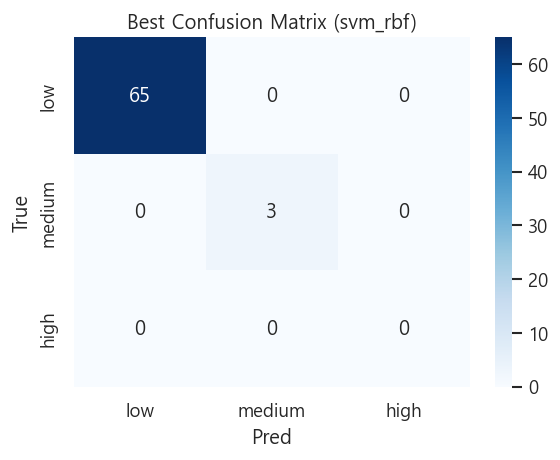

classification report


,precision,recall,f1-score,support
low,1.000000,1.000000,1.000000,65.0
medium,1.000000,1.000000,1.000000,3.0
high,0.000000,0.000000,0.000000,0.0
macro avg,0.666667,0.666667,0.666667,68.0
weighted avg,1.000000,1.000000,1.000000,68.0


In [13]:
def _score_for_selection(r: dict[str, Any]) -> float:
    # 정확도보다 macro/high recall과 일반화 갭 중심
    overfit_gap = r["train_accuracy"] - r["test_accuracy"]
    interp_bonus = 0.02 if r["model_name"] in ["random_forest", "logistic_regression"] else 0.0
    return (
        1.00 * r["test_macro_f1"]
        + 0.35 * (0.6 * r["high_recall"] + 0.4 * r["medium_recall"])
        - 0.20 * max(overfit_gap, 0.0)
        + interp_bonus
    )

cand = [
    r for r in results
    if (r["feature_set"] in ["A_strict_anti_leakage", "B_moderate_anti_leakage"])
    and (r["split_mode"] in ["group", "time"])
]
if not cand:
    raise RuntimeError("best model 후보가 없습니다.")

cand_sorted = sorted(cand, key=_score_for_selection, reverse=True)
best_res = cand_sorted[0]

print("BEST (선정 기준 기반)")
print({
    "feature_set": best_res["feature_set"],
    "split_mode": best_res["split_mode"],
    "model_name": best_res["model_name"],
    "test_acc": round(best_res["test_accuracy"], 4),
    "macro_f1": round(best_res["test_macro_f1"], 4),
    "high_recall": round(best_res["high_recall"], 4),
    "medium_recall": round(best_res["medium_recall"], 4),
})

# class distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
tr = best_res["y_train"].value_counts().reindex(LABEL_ORDER).fillna(0)
te = best_res["y_test"].value_counts().reindex(LABEL_ORDER).fillna(0)
sns.barplot(x=tr.index, y=tr.values, ax=axes[0], palette="Blues")
axes[0].set_title("train class distribution")
sns.barplot(x=te.index, y=te.values, ax=axes[1], palette="Oranges")
axes[1].set_title("test class distribution")
plt.tight_layout()
plt.show()

# confusion matrix
cm = best_res["confusion_matrix"]
fig2, ax2 = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER, ax=ax2)
ax2.set_title(f"Best Confusion Matrix ({best_res['model_name']})")
ax2.set_xlabel("Pred")
ax2.set_ylabel("True")
plt.tight_layout()
plt.show()

print("classification report")
display(pd.DataFrame(best_res["classification_report"]).T.loc[LABEL_ORDER + ["macro avg", "weighted avg"]])

## 10. ML refinement 추가 실험: score 회귀(보조)

분류만이 아니라 `risk_score_rule` 연속값 회귀를 보조적으로 수행해 ranking 안정성을 확인합니다.

In [14]:
from sklearn.ensemble import HistGradientBoostingRegressor


def run_regression_refinement(df: pd.DataFrame, feature_cols: list[str], split_mode: str = "group"):
    sp = split_data(df, feature_cols, split_mode=split_mode)
    X_train, X_test = sp["X_train"], sp["X_test"]
    y_train = sp["train_df"]["risk_score_rule"].to_numpy()
    y_test = sp["test_df"]["risk_score_rule"].to_numpy()
    y_test_label = sp["y_test"]

    models = {
        "rf_reg": RandomForestRegressor(n_estimators=260, max_depth=10, random_state=SEED, n_jobs=-1),
        "hgb_reg": HistGradientBoostingRegressor(max_depth=8, learning_rate=0.06, max_iter=240, random_state=SEED),
    }

    rows = []
    pred_cache = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = np.clip(model.predict(X_test), 0.0, 1.0)
        pred_cache[name] = pred

        rk = ranking_metrics(y_test_label, pred, ks=[5, 10, 20])
        rows.append(
            {
                "model": name,
                "split_mode": split_mode,
                "mae": mean_absolute_error(y_test, pred),
                "r2": r2_score(y_test, pred),
                **rk,
            }
        )

    return pd.DataFrame(rows), pred_cache, sp


reg_table, reg_pred_cache, reg_split = run_regression_refinement(
    risk_df,
    feature_sets["A_strict_anti_leakage"],
    split_mode="group",
)

print("회귀 보조 실험 결과")
display(reg_table.round(4))

회귀 보조 실험 결과


,model,split_mode,mae,r2,precision@5,recall@5,hit@5,precision@10,recall@10,hit@10,precision@20,recall@20,hit@20
0,rf_reg,group,0.0199,0.6486,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,hgb_reg,group,0.0194,0.6607,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 11. Feature Importance / Permutation Importance

해당 모델은 내장 importance를 제공하지 않습니다.


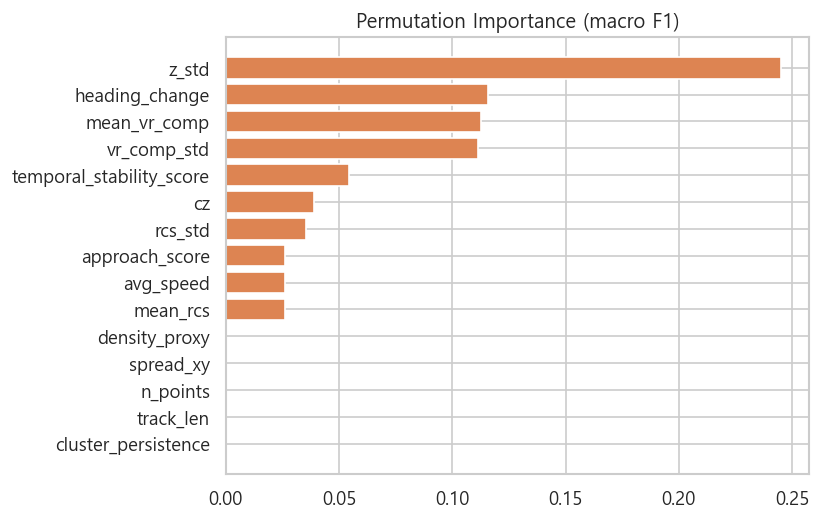

,perm_importance
z_std,0.245090
heading_change,0.115696
mean_vr_comp,0.112635
vr_comp_std,0.111247
temporal_stability_score,0.054254
cz,0.038931
rcs_std,0.035428
approach_score,0.025954
avg_speed,0.025954
mean_rcs,0.025954


In [15]:
from sklearn.inspection import permutation_importance

feature_cols_best = best_res["feature_cols"]
model_best = best_res["model"]
X_test_best = best_res["X_test"]
y_test_best = best_res["y_test"]

imp_series = None
if hasattr(model_best, "feature_importances_"):
    imp_series = pd.Series(model_best.feature_importances_, index=feature_cols_best)
elif isinstance(model_best, Pipeline) and hasattr(model_best.steps[-1][1], "feature_importances_"):
    imp_series = pd.Series(model_best.steps[-1][1].feature_importances_, index=feature_cols_best)

if imp_series is not None:
    imp_sorted = imp_series.sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(7, max(4, len(imp_sorted) * 0.30)))
    ax.barh(imp_sorted.index[::-1], imp_sorted.values[::-1], color="#4c72b0")
    ax.set_title("Model Feature Importance")
    plt.tight_layout()
    plt.show()
else:
    print("해당 모델은 내장 importance를 제공하지 않습니다.")

perm = permutation_importance(
    model_best,
    X_test_best,
    y_test_best,
    scoring="f1_macro",
    n_repeats=8,
    random_state=SEED,
    n_jobs=1,
)
perm_series = pd.Series(perm.importances_mean, index=feature_cols_best).sort_values(ascending=False)
fig2, ax2 = plt.subplots(figsize=(7, max(4, len(perm_series) * 0.30)))
ax2.barh(perm_series.index[::-1], perm_series.values[::-1], color="#dd8452")
ax2.set_title("Permutation Importance (macro F1)")
plt.tight_layout()
plt.show()

display(perm_series.to_frame("perm_importance"))

## 12. Step 8 — Hybrid Risk 결합 + BEV 위험지역 시각화

최종 위험도는 rule-based baseline과 ML refinement를 결합합니다.

- `risk_score_rule` (운영 baseline)
- `risk_score_ml` (보조 추론)
- `risk_confidence_ml` (ML 신뢰도)
- `risk_score_hybrid` (최종 우선순위 점수)

In [16]:
# best 설정으로 전체 데이터에 ML refinement 적용
best_features = best_res["feature_cols"]
best_model_name = best_res["model_name"]

X_all = risk_df[best_features].replace([np.inf, -np.inf], np.nan)
X_all = X_all.fillna(X_all.median(numeric_only=True))
y_all = risk_df["risk_label_ml_target"].astype(str)

model_all = build_model(best_model_name)
model_all = _fit_with_weight(model_all, X_all, y_all)

if hasattr(model_all, "predict_proba"):
    proba_all = model_all.predict_proba(X_all)
    classes_all = list(model_all.classes_)
elif isinstance(model_all, Pipeline) and hasattr(model_all.steps[-1][1], "predict_proba"):
    proba_all = model_all.predict_proba(X_all)
    classes_all = list(model_all.steps[-1][1].classes_)
else:
    pred_all = model_all.predict(X_all)
    classes_all = LABEL_ORDER
    proba_all = np.zeros((len(pred_all), len(classes_all)))
    idx_map = {c: i for i, c in enumerate(classes_all)}
    pidx = pd.Series(pred_all).map(idx_map).fillna(0).astype(int).to_numpy()
    proba_all[np.arange(len(pred_all)), pidx] = 1.0

risk_df["risk_score_ml"] = _risk_score_from_proba(classes_all, proba_all)
risk_df["risk_confidence_ml"] = np.max(proba_all, axis=1)

# hybrid 결합: rule baseline 비중을 높게 유지
risk_df["risk_score_hybrid"] = np.clip(
    0.75 * risk_df["risk_score_rule"] + 0.25 * risk_df["risk_score_ml"],
    0.0,
    1.0,
)

# hybrid 라벨: quantile + 물리·LiDAR 게이트 (v2.assign_hybrid_labels_from_scores)
risk_df["risk_label_hybrid"] = v2.assign_hybrid_labels_from_scores(risk_df, "risk_score_hybrid")

print("hybrid label 분포")
display(risk_df["risk_label_hybrid"].value_counts().reindex(LABEL_ORDER).fillna(0).astype(int).to_frame("count"))

# top risk candidates
top_cols = [
    "frame_id", "cluster_id", "track_id", "risk_score_rule", "risk_score_ml", "risk_confidence_ml", "risk_score_hybrid", "risk_label_hybrid",
    "cx", "cy", "range_xy", "abs_vr_comp", "track_len", "approach_score", "lidar_corroboration_score",
]
display(risk_df[top_cols].sort_values("risk_score_hybrid", ascending=False).head(20))

hybrid label 분포


,count
risk_label_hybrid,
low,259
medium,26
high,0


,frame_id,cluster_id,track_id,risk_score_rule,risk_score_ml,risk_confidence_ml,risk_score_hybrid,risk_label_hybrid,cx,cy,range_xy,abs_vr_comp,track_len,approach_score,lidar_corroboration_score
184,00120,1,30,0.512788,0.587312,0.971805,0.531419,medium,3.002413,2.915708,4.185193,2.803187,3,0.059782,0.802353
182,00119,1,30,0.509540,0.586511,0.970024,0.528783,medium,3.049946,3.122023,4.364539,2.800286,3,0.059782,0.800750
237,00159,1,40,0.508346,0.578655,0.952566,0.525923,medium,24.714582,1.767195,24.777683,20.148270,2,0.000000,0.668988
180,00118,1,30,0.508144,0.578631,0.952512,0.525766,medium,3.059265,2.846674,4.178834,2.686594,3,0.059782,0.802054
231,00156,1,39,0.492173,0.582752,0.961672,0.514818,medium,27.662624,4.363926,28.004725,20.325533,3,0.079675,0.660667
233,00157,1,39,0.492068,0.582766,0.961702,0.514742,medium,27.551350,3.443427,27.765699,20.325533,3,0.079675,0.639205
239,00160,1,40,0.488128,0.578668,0.952594,0.510763,medium,27.605333,1.644643,27.654282,20.303194,2,0.000000,0.654941
235,00158,1,39,0.483116,0.578617,0.952482,0.506991,medium,29.074799,3.051526,29.234495,20.280342,3,0.079675,0.652395
207,00137,1,35,0.482648,0.578669,0.952598,0.506654,medium,5.122215,5.747308,7.698613,3.612334,3,0.067301,0.706820
209,00138,1,35,0.479012,0.588287,0.973971,0.506331,medium,5.418212,5.751609,7.901774,3.542159,3,0.067301,0.734615


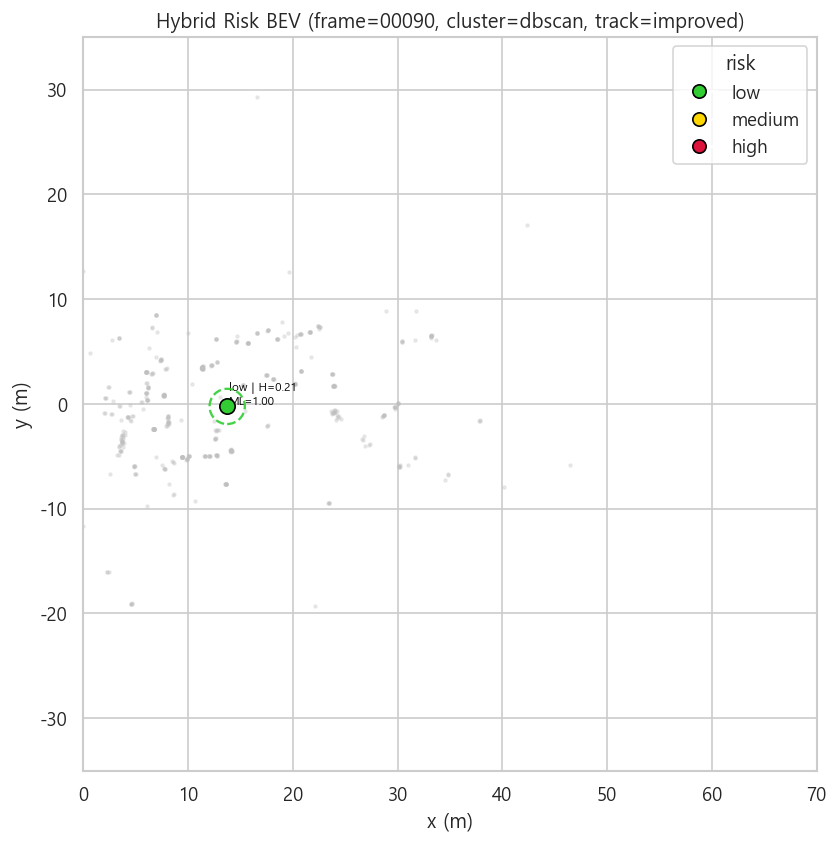

In [17]:
def bev_visualize_frame(frame_id: str, save_path: Path | None = None):
    fr_pts = radar_df[radar_df["frame_id"] == frame_id]
    fr_clu = risk_df[risk_df["frame_id"] == frame_id].copy()

    if fr_pts.empty or fr_clu.empty:
        print(f"frame {frame_id} 데이터 부족")
        return None

    fig, ax = plt.subplots(figsize=(9.2, 7.2))

    # 1) raw radar points
    ax.scatter(fr_pts["x"], fr_pts["y"], s=3, c="0.75", alpha=0.28, label="raw radar")

    # 2) track arrow (직전 프레임 대비)
    prev_order = int(fr_clu["frame_order"].iloc[0]) - 1
    prev_df = risk_df[risk_df["frame_order"] == prev_order][["track_id", "cx", "cy"]].copy()
    prev_map = {int(r.track_id): (float(r.cx), float(r.cy)) for r in prev_df.itertuples(index=False) if int(r.track_id) >= 0}

    for r in fr_clu.itertuples(index=False):
        tid = int(r.track_id)
        if tid in prev_map:
            px, py = prev_map[tid]
            ax.arrow(px, py, float(r.cx - px), float(r.cy - py), head_width=0.35, head_length=0.55, fc="royalblue", ec="royalblue", alpha=0.55, length_includes_head=True)

    # 3) cluster center + risk zones + text
    c_map = {"low": "limegreen", "medium": "gold", "high": "crimson"}
    for r in fr_clu.itertuples(index=False):
        color = c_map.get(r.risk_label_hybrid, "gray")
        ax.scatter(r.cx, r.cy, c=color, s=85, edgecolor="black", zorder=6)
        radius = 1.1 + 2.8 * float(r.risk_score_hybrid)
        ax.add_patch(Circle((r.cx, r.cy), radius=radius, fill=False, linestyle="--", linewidth=1.4, color=color, alpha=0.9, zorder=5))
        ax.text(
            r.cx + 0.2,
            r.cy + 0.25,
            f"{r.risk_label_hybrid} | H={r.risk_score_hybrid:.2f}\nML={r.risk_confidence_ml:.2f}",
            fontsize=7,
            color="black",
        )

    ax.set_title(f"Hybrid Risk BEV (frame={frame_id}, cluster={SELECTED_CLUSTER_ALGO}, track={TRACK_MODE})")
    ax.set_xlim(ROI["x_min"], ROI["x_max"])
    ax.set_ylim(ROI["y_min"], ROI["y_max"])
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_aspect("equal")

    handles = [
        plt.Line2D([0], [0], marker="o", color="w", label="low", markerfacecolor="limegreen", markeredgecolor="black", markersize=8),
        plt.Line2D([0], [0], marker="o", color="w", label="medium", markerfacecolor="gold", markeredgecolor="black", markersize=8),
        plt.Line2D([0], [0], marker="o", color="w", label="high", markerfacecolor="crimson", markeredgecolor="black", markersize=8),
    ]
    ax.legend(handles=handles, title="risk", loc="upper right")

    plt.tight_layout()
    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=170, bbox_inches="tight")
    plt.show()
    return fig


_ = bev_visualize_frame(DEMO_FRAME_ID)

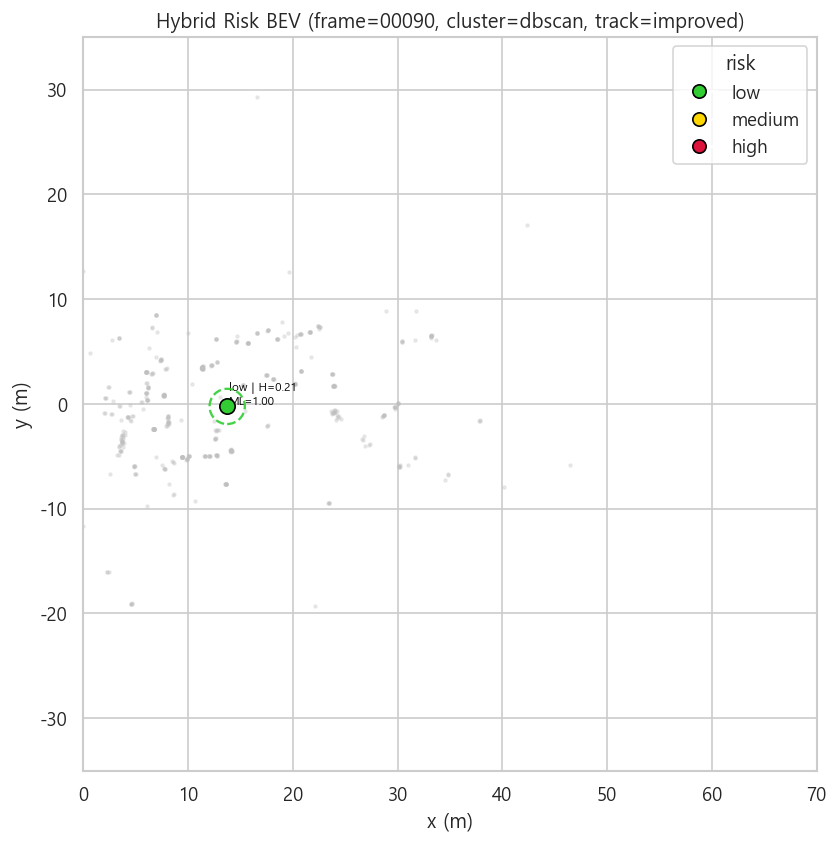

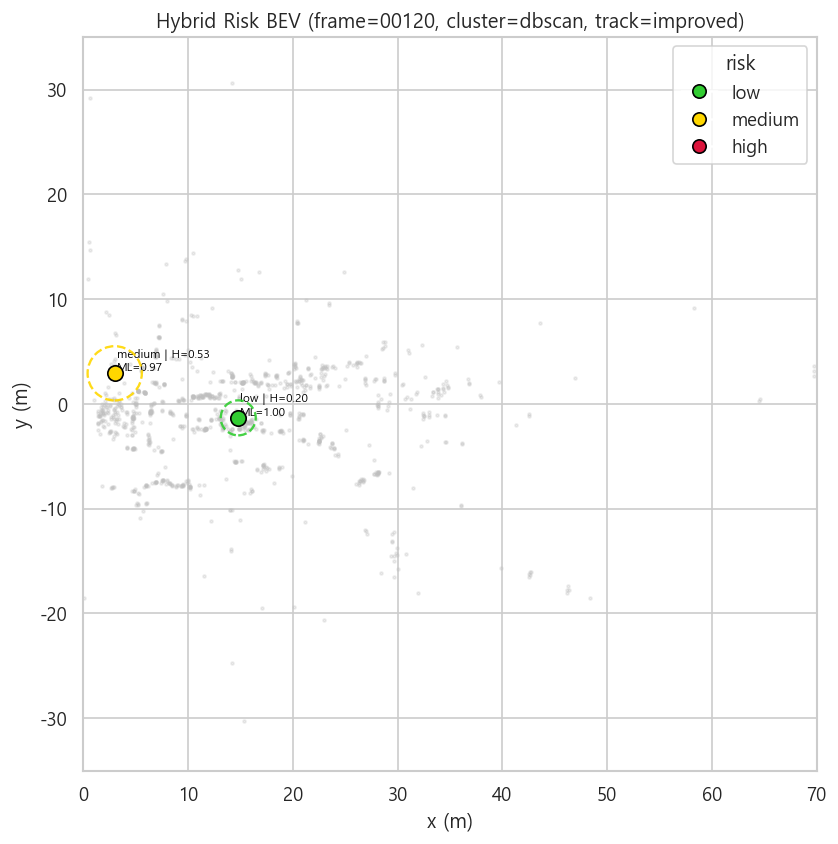

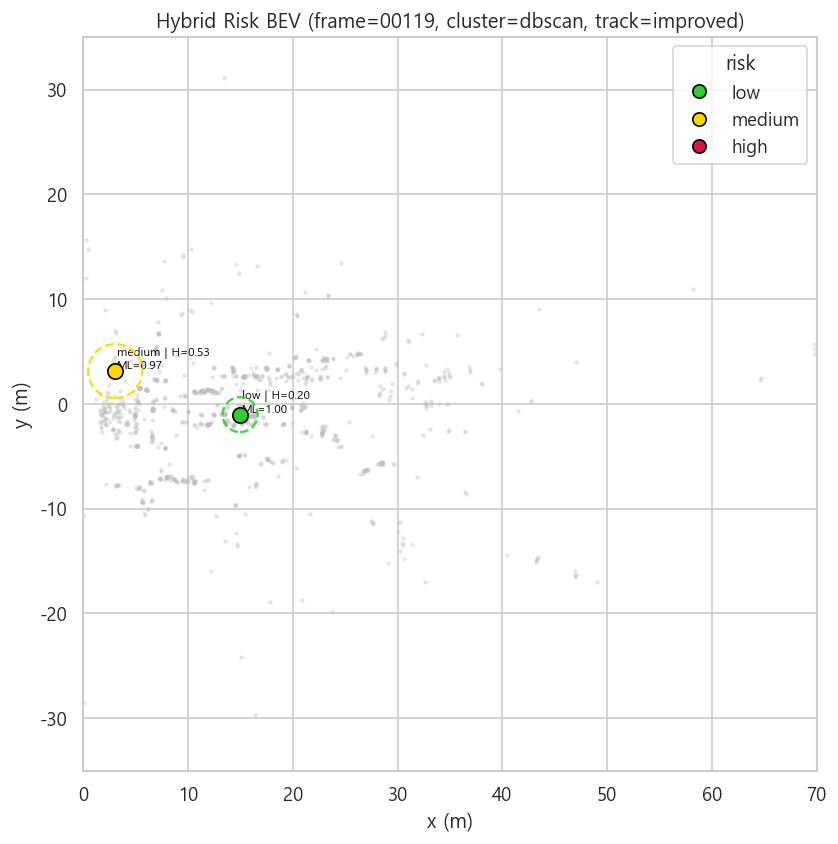

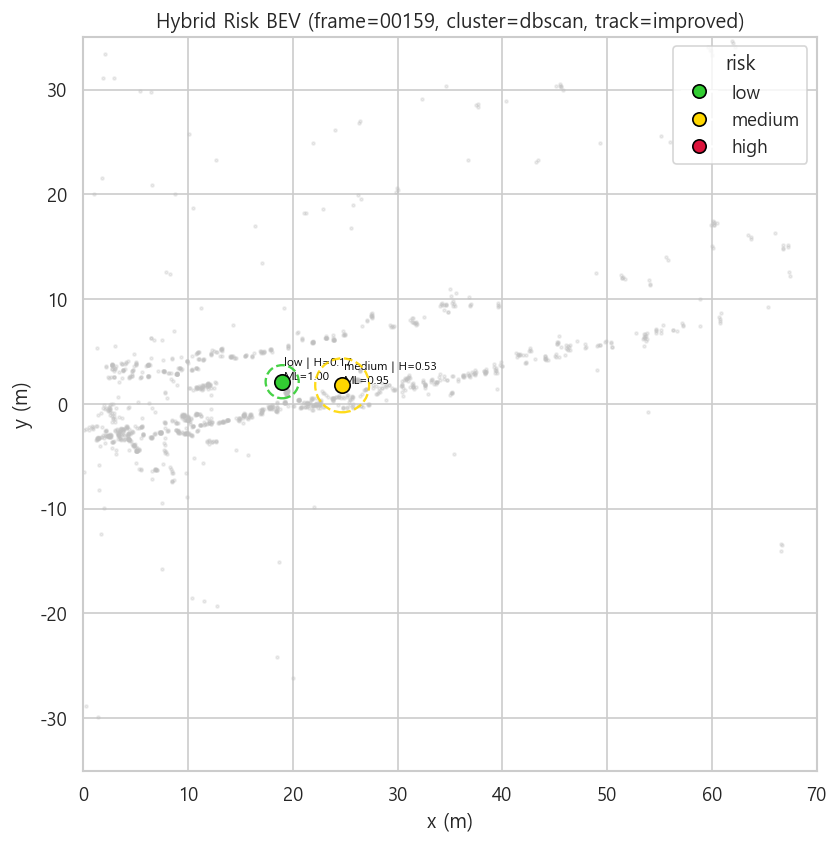

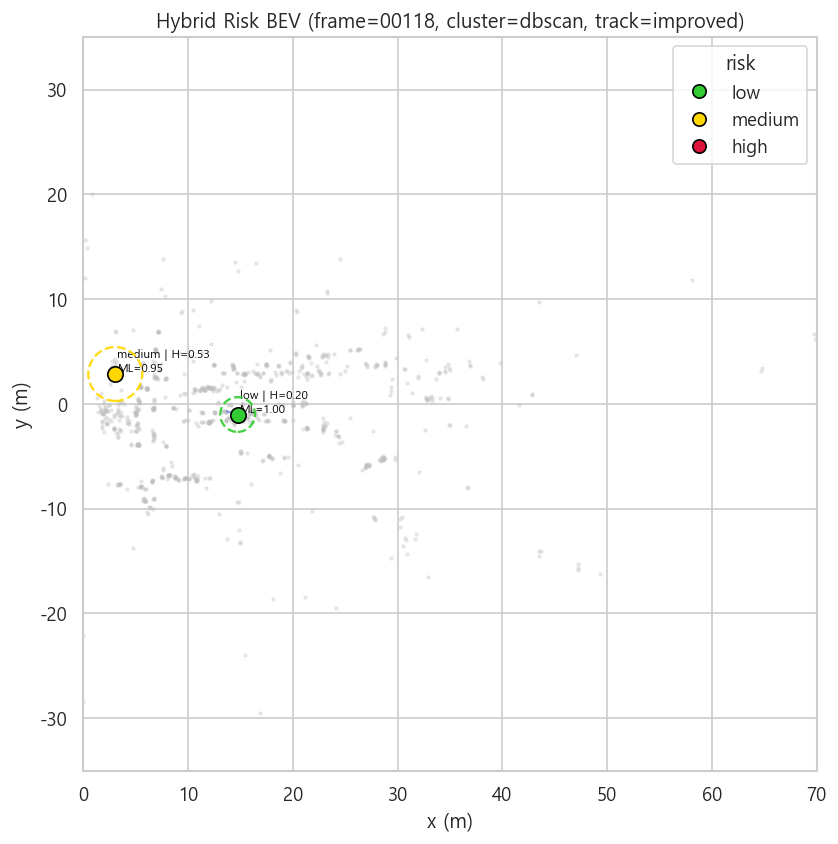

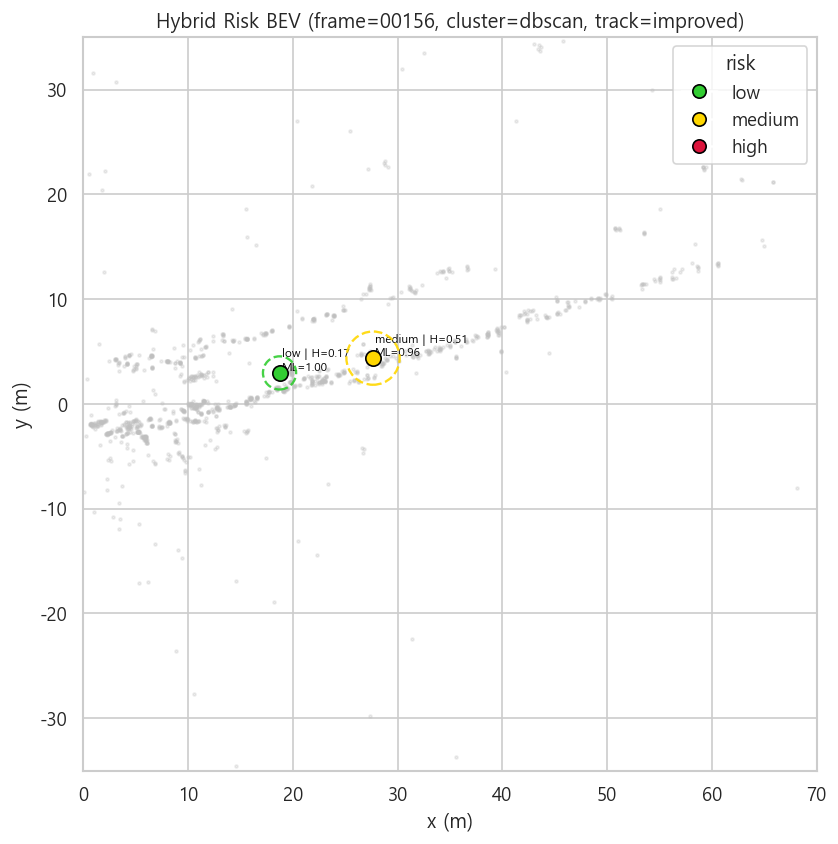

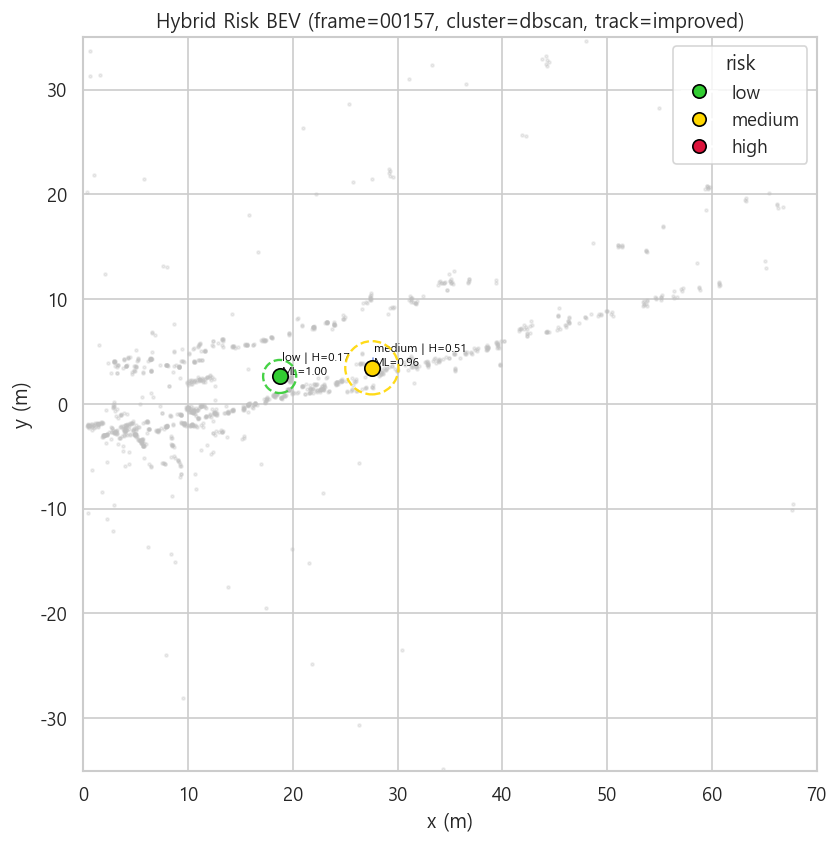

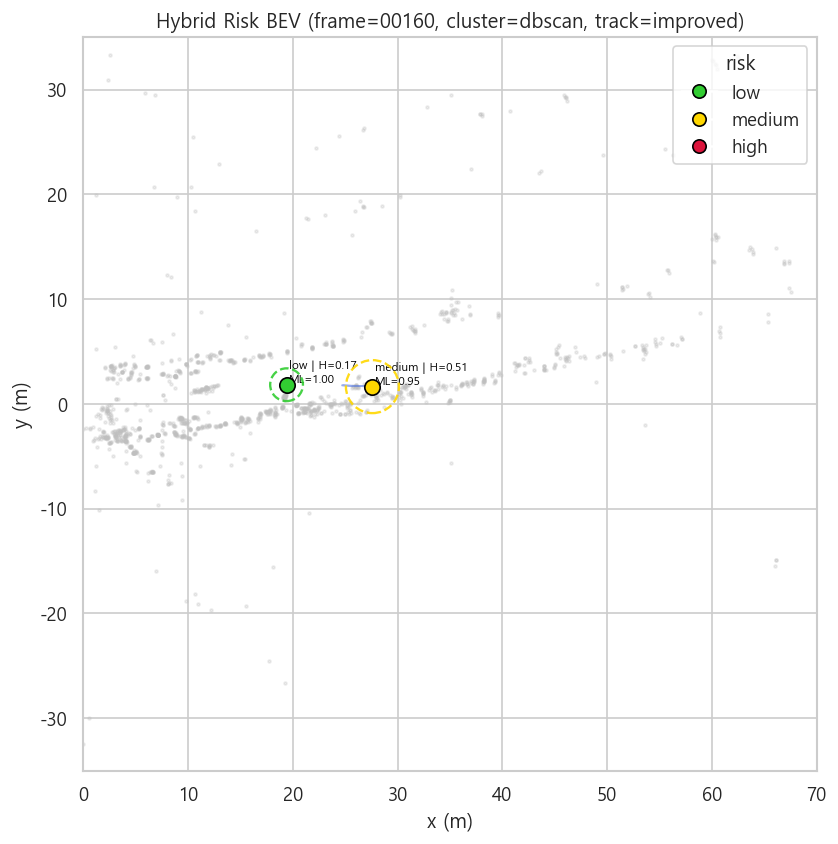

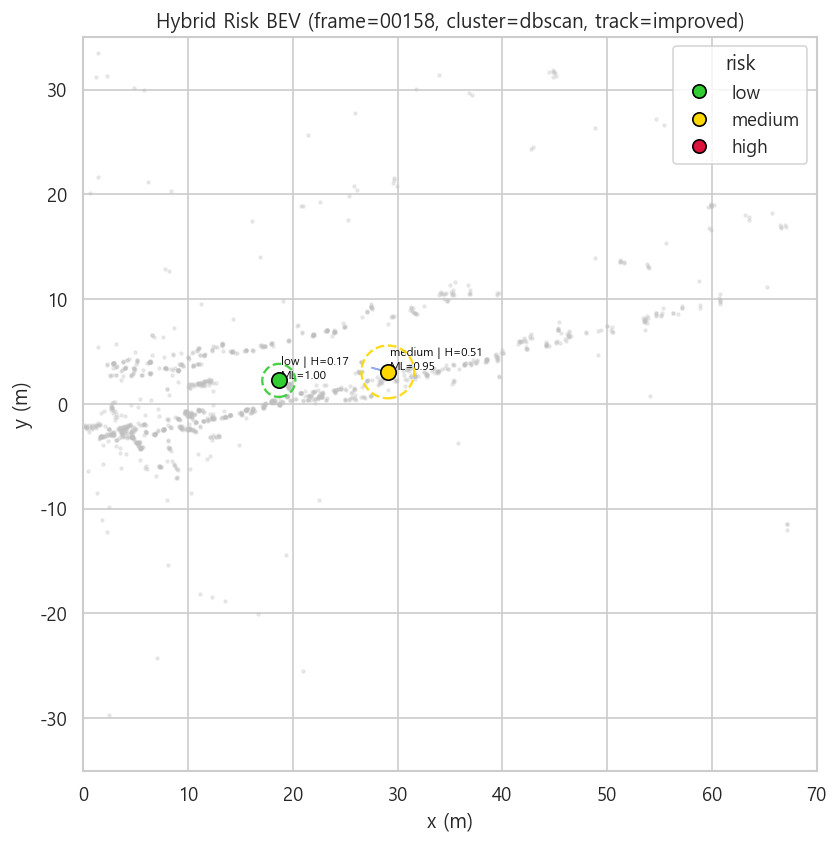

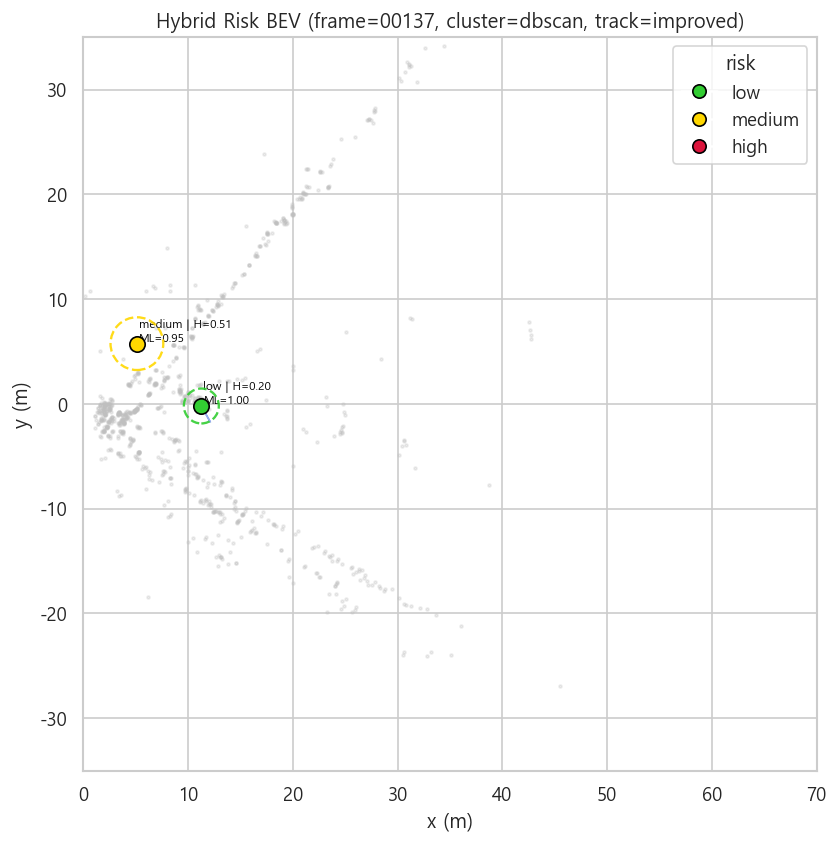

저장된 PNG
 - C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\artifacts\vod_redesign_figures\bev_hybrid_00090.png
 - C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\artifacts\vod_redesign_figures\bev_hybrid_00120.png
 - C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\artifacts\vod_redesign_figures\bev_hybrid_00119.png
 - C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\artifacts\vod_redesign_figures\bev_hybrid_00159.png
 - C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\artifacts\vod_redesign_figures\bev_hybrid_00118.png
 - C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\artifacts\vod_redesign_figures\bev_hybrid_00156.png
 - C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\artifacts\vod_redesign_figures\bev_hybrid_00157.png
 - C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\artifacts\vod_redesign_figures\bev_hybrid_00160.png
 - C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\artifacts\vod_redesign_figures\bev_hybrid_001

In [18]:
# 발표용 그림 저장 + (가능 시) GIF 생성
OUT_DIR = NOTEBOOK_DIR / "artifacts" / "vod_redesign_figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 위험 후보가 많은 프레임 우선 저장
frame_rank = (
    risk_df.groupby("frame_id")["risk_score_hybrid"].max().sort_values(ascending=False)
)
sel_frames = [DEMO_FRAME_ID] + [f for f in frame_rank.index.tolist() if f != DEMO_FRAME_ID][:9]

saved_paths = []
for fid in sel_frames:
    out = OUT_DIR / f"bev_hybrid_{fid}.png"
    fig = bev_visualize_frame(fid, save_path=out)
    if fig is not None:
        saved_paths.append(out)

print("저장된 PNG")
for p in saved_paths:
    print(" -", p)

# GIF (옵션)
try:
    import imageio.v2 as imageio

    imgs = [imageio.imread(str(p)) for p in saved_paths]
    if imgs:
        gif_path = OUT_DIR / "bev_hybrid_sequence.gif"
        imageio.mimsave(str(gif_path), imgs, duration=0.55)
        print("GIF 저장:", gif_path)
except Exception as e:
    print("GIF 생성 생략:", str(e)[:180])

## 13. 왜 accuracy보다 macro F1을 봐야 하는가

현재 라벨 분포는 보통 `low`가 압도적이고 `high`는 매우 희소합니다.

- 이때 accuracy는 low를 잘 맞히는 것만으로도 높게 나올 수 있습니다.
- 반면 macro F1은 클래스별 F1을 균등 평균하므로 medium/high 성능 저하를 숨기기 어렵습니다.
- 따라서 위험도 파이프라인에서는 `macro F1`, `high/medium recall`, `confusion matrix`를 핵심 지표로 봐야 합니다.

### leakage vs honest 비교 해석
- leakage+random에서는 acc/macro F1이 높게 보일 수 있습니다.
- anti-leakage + group/time에서는 점수가 내려가더라도 이것이 더 현실적이고 신뢰 가능한 평가입니다.

## 14. 발표용 최종 결론 (복사용)

1. **VoD에서는 high class가 매우 희소**하므로, 완벽한 3-class 분류기보다 위험 후보 **우선순위화(ranking)**가 더 적절하다.
2. **Rule-based risk가 운영 baseline**, ML은 refinement/confidence를 제공하는 보조 모델이 더 적절하다.
3. **Leakage 제거와 group/time split은 필수**이며, random split 중심 평가는 성능을 과대평가할 수 있다.
4. **accuracy보다 macro F1과 high/medium recall이 중요**하다. 클래스 불균형에서 accuracy는 착시를 만든다.
5. 최종 목표는 "무엇인지 완벽히 맞히는 것"이 아니라, **"어디가 위험한지 먼저 보여주는 것"**이다.

---

### 모델 계층 요약
- LogisticRegression: 선형 기준선(최소 baseline)
- RandomForest: 비선형 baseline + 해석 용이
- HistGradientBoosting: 고급 tabular 모델(복잡 상호작용)
- SVM(RBF): 복잡 경계 가능하나 계산 부담 존재

고급 모델이 항상 더 좋은 것은 아니다. 누설 구조에서는 오히려 더 잘 외워서 더 위험할 수 있으므로, **모델 복잡도보다 평가 구조의 정직성**이 우선이다.